# Лабораторная работа: Полный цикл обработки больших данных
## Малые и средние предприятия лёгкой промышленности России (2016–2023)

**Пайплайн:** сбор и подготовка данных → хранение и ETL → аналитика и закономерности → прогнозные модели → интерактивный дашборд

**Данные:** открытые наборы ФНС России — Единый реестр субъектов МСП, сведения о доходах/расходах и среднесписочной численности работников организаций лёгкой промышленности (ОКВЭД 13 «Текстильное производство», 14 «Производство одежды», 15 «Производство кожи и изделий из кожи»).

**Правовой контур:** 152-ФЗ «О персональных данных», 242-ФЗ «О внесении изменений...» (локализация), ГОСТ Р ИСО/МЭК 27001 (меры защиты информации).

## Оглавление
1. [Этап 1. Сбор и подготовка данных](#etap1) — очистка, аудит ПДн, паспорт данных
2. [Этап 2. Хранение и первичная обработка](#etap2) — СУБД DuckDB, ETL, контроль качества
3. [Этап 3. Аналитика и поиск закономерностей](#etap3) — распределения, корреляции, карта, аномалии
4. [Этап 4. Прогнозная аналитика](#etap4) — тренд, ML-модели (CatBoost + RandomForest), «что если», кластеризация
5. [Этап 5. Финальный дашборд](#etap5) — интерактивный BI-отчёт
6. [Этап 6. Бизнес-блок](#etap6) — 152-ФЗ, интерпретация vs манипуляция, стоимость ошибки
7. [Итоговый отчёт](#etap7)

## 0. Окружение и импорты

In [1]:
import hashlib
import json
import warnings
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATA_DIR = Path("data")
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)
DB_PATH = OUT_DIR / "lab01.duckdb"
GEO_PATH = DATA_DIR / "geo" / "ne_50m_admin1.geojson"  # Natural Earth 1:50m — лёгкая геометрия для быстрых карт
SALT = "lab01-msp-light-industry"  # соль для обезличивания ИНН

print(f"pandas {pd.__version__} | numpy {np.__version__} | duckdb {duckdb.__version__}")
print(f"Рабочая папка: {Path.cwd()}")

pandas 3.0.6 | numpy 2.5.3 | duckdb 1.5.6
Рабочая папка: D:\Projects\TrainProject\Lab01


# <a id="etap1"></a>Этап 1. Сбор и подготовка данных

## 1.1. Паспорт данных

| Атрибут | Значение |
|---|---|
| **Источник** | Открытые данные ФНС России: «Единый реестр субъектов МСП» (7707329152-rsmp), «Доходы и расходы организаций» (7707329152-revexp), «Среднесписочная численность работников» (7707329152-sshr2019); постобработка: Сёмин П.О. (ПГНИУ), лицензия CC BY-SA |
| **Объект** | Юридические лица — субъекты малого и среднего предпринимательства лёгкой промышленности (основной ОКВЭД начинается с 13, 14 или 15) |
| **Период** | август 2016 — ноябрь 2023 (сведения реестра); финансовые показатели: 2018–2022 |
| **Объём** | smb.csv — 36 213 записей; revexp.csv — 80 963; empl.csv — 84 976; panel.csv — 146 561 |
| **География** | 83 субъекта РФ, адреса нормализованы до населённого пункта, есть координаты (EPSG:4326) и ОКТМО |
| **Ключевые поля** | ИНН, категория МСП (1 — микро, 2 — малое, 3 — среднее), ОКВЭД, регион, доходы, расходы, среднесписочная численность |

**Состав исходных таблиц:**
- `smb.csv` — «медленная» таблица реестра: варианты сведений об организации с периодами актуальности (`start_date`–`end_date`);
- `revexp.csv` — годовые доходы/расходы по ИНН;
- `empl.csv` — годовая среднесписочная численность по ИНН;
- `panel.csv` — производная панельная таблица (объединение трёх предыдущих) — используем для сверки.

## 1.2. Загрузка и первичный осмотр

In [2]:
dtypes = {"tin": str, "reg_number": str, "oktmo": str}
smb_raw = pd.read_csv(DATA_DIR / "smb.csv", sep=";", dtype=dtypes)
rev_raw = pd.read_csv(DATA_DIR / "revexp.csv", sep=";", dtype={"tin": str})
emp_raw = pd.read_csv(DATA_DIR / "empl.csv", sep=";", dtype={"tin": str})
panel_raw = pd.read_csv(DATA_DIR / "panel.csv", sep=";", dtype=dtypes)

display(Markdown("**Размеры загруженных таблиц:**"))
overview = pd.DataFrame(
    {
        "Таблица": ["smb.csv", "revexp.csv", "empl.csv", "panel.csv"],
        "Строк": [len(smb_raw), len(rev_raw), len(emp_raw), len(panel_raw)],
        "Столбцов": [smb_raw.shape[1], rev_raw.shape[1], emp_raw.shape[1], panel_raw.shape[1]],
        "Уникальных ИНН": [smb_raw["tin"].nunique(), rev_raw["tin"].nunique(),
                           emp_raw["tin"].nunique(), panel_raw["tin"].nunique()],
    }
)
display(overview)

**Размеры загруженных таблиц:**

,Таблица,Строк,Столбцов,Уникальных ИНН
0,smb.csv,36213,16,31088
1,revexp.csv,80963,4,22513
2,empl.csv,84976,3,23554
3,panel.csv,146561,19,31088


In [3]:
display(Markdown("**Пример записей реестра (smb.csv):**"))
display(smb_raw.head(3).T)
display(Markdown("**Пример финансовых данных (revexp.csv):**"))
display(rev_raw.head(3))

**Пример записей реестра (smb.csv):**

,0,1,2
tin,0323389352,0323397610,0542002689
reg_number,NaN,NaN,1020502003246
category,1,1,1
org_name,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""Я-КОЖ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ИННОВА""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ФАБР..."
org_short_name,"ООО ""Я-КОЖ""","ООО ""ИННОВА""","ООО ""ФАБРИКА ""ДАГЮН"""
activity_code_main,15.12,15.20.13,13.10.2
region,Республика Бурятия,Республика Бурятия,Республика Дагестан
area,NaN,NaN,NaN
settlement,Улан-Удэ,Улан-Удэ,Дербент
settlement_type,г,г,г


**Пример финансовых данных (revexp.csv):**

,tin,year,revenue,expenditure
0,0100002516,2022,"889,000.00","367,000.00"
1,0105026430,2018,"214,751,008.00","180,732,000.00"
2,0105026430,2019,"200,076,992.00","170,624,992.00"


## 1.3. Первичная очистка данных

### 1.3.1. Дубликаты

In [4]:
dup_report = []
for name, df in [("smb", smb_raw), ("revexp", rev_raw), ("empl", emp_raw), ("panel", panel_raw)]:
    dup_report.append(
        {"Таблица": name,
         "Полных дубликатов строк": int(df.duplicated().sum()),
         "Повторов ключа (tin)": int(df["tin"].duplicated().sum())}
    )
display(pd.DataFrame(dup_report))

,Таблица,Полных дубликатов строк,Повторов ключа (tin)
0,smb,0,5125
1,revexp,0,58450
2,empl,0,61422
3,panel,0,115473


In [5]:
# Повторы tin в smb — это НЕ мусор: реестр хранит историю изменений сведений
# (у одной организации несколько периодов актуальности). Проверим уникальность
# естественного ключа: (tin, start_date, end_date).
key_dup = smb_raw.duplicated(subset=["tin", "start_date", "end_date"]).sum()
print(f"Дубликатов по ключу (tin, start_date, end_date): {key_dup}")

# Повторы (tin, year) в revexp/empl — проверим, есть ли конфликты значений
for name, df, col in [("revexp", rev_raw, "revenue"), ("empl", emp_raw, "employees_count")]:
    d = df.duplicated(subset=["tin", "year"]).sum()
    print(f"{name}: дубликатов ключа (tin, year): {d}")

Дубликатов по ключу (tin, start_date, end_date): 0
revexp: дубликатов ключа (tin, year): 0
empl: дубликатов ключа (tin, year): 0


In [6]:
# Устраняем точные дубликаты ключей, оставляя первую запись (в исходных данных их нет —
# но пайплайн должен быть устойчив к «грязным» повторным выгрузкам)
smb = smb_raw.drop_duplicates(subset=["tin", "start_date", "end_date"]).copy()
rev = rev_raw.drop_duplicates(subset=["tin", "year"]).copy()
emp = emp_raw.drop_duplicates(subset=["tin", "year"]).copy()
print(f"После дедупликации: smb {len(smb)}, revexp {len(rev)}, empl {len(emp)}")

После дедупликации: smb 36213, revexp 80963, empl 84976


### 1.3.2. Типы данных и даты в едином формате

Приводим даты к типу `datetime` для обработки; при выгрузке очищенного CSV (п. 1.6) сохраним их в требуемом российском формате **ДД.ММ.ГГГГ**.

In [7]:
smb["start_date"] = pd.to_datetime(smb["start_date"], errors="coerce")
smb["end_date"] = pd.to_datetime(smb["end_date"], errors="coerce")
rev["year"] = rev["year"].astype(int)
emp["year"] = emp["year"].astype(int)

bad_dates = smb["start_date"].isna().sum() + smb["end_date"].isna().sum()
print(f"Некорректных дат: {bad_dates}")
print(f"Период сведений реестра: {smb['start_date'].min():%d.%m.%Y} — {smb['end_date'].max():%d.%m.%Y}")
print(f"Годы финансовых данных: {rev['year'].min()}–{rev['year'].max()}; численность: {emp['year'].min()}–{emp['year'].max()}")

Некорректных дат: 0
Период сведений реестра: 10.08.2016 — 10.11.2023
Годы финансовых данных: 2018–2022; численность: 2018–2022


### 1.3.3. Пропуски и «мусорные» значения

In [8]:
na = pd.DataFrame({
    "Пропусков, шт.": smb.isna().sum(),
    "Пропусков, %": (smb.isna().mean() * 100).round(1),
}).query("`Пропусков, шт.` > 0").sort_values("Пропусков, шт.", ascending=False)
display(na)

,"Пропусков, шт.","Пропусков, %"
area,30581,84.40
reg_number,12739,35.20
settlement,9850,27.20
oktmo,672,1.90
lat,567,1.60
settlement_type,567,1.60
lon,567,1.60
org_short_name,93,0.30


In [9]:
# oktmo в исходнике сохранён как число (потеряны ведущие нули) — восстанавливать не будем:
# геопривязка обеспечена полями lat/lon и названием региона.
# 'NaN'-подобные значения в текстовых полях:
for c in ["region", "settlement", "area", "settlement_type"]:
    weird = smb[c].astype(str).str.strip().isin(["", "nan", "None", "NULL"]).sum()
    print(f"{c}: пустых/мусорных строк — {weird}")

# Ключевое поле region заполнено полностью (0 пропусков) — геоанализ возможен для всех записей.
# Явные нули/отрицательные значения в показателях:
display(pd.DataFrame({
    "Показатель": ["revenue <= 0", "expenditure < 0", "employees_count = 0"],
    "Записей, шт.": [(rev["revenue"] <= 0).sum(), (rev["expenditure"] < 0).sum(), (emp["employees_count"] == 0).sum()],
    "Доля, %": [round((rev["revenue"] <= 0).mean() * 100, 1),
                round((rev["expenditure"] < 0).mean() * 100, 1),
                round((emp["employees_count"] == 0).mean() * 100, 1)],
}))

region: пустых/мусорных строк — 0
settlement: пустых/мусорных строк — 0
area: пустых/мусорных строк — 0
settlement_type: пустых/мусорных строк — 0


,Показатель,"Записей, шт.","Доля, %"
0,revenue <= 0,17394,21.50
1,expenditure < 0,1,0.00
2,employees_count = 0,10933,12.90


In [10]:
# Решения по очистке:
# 1) Нулевые/отрицательные доходы — это не ошибка, а Feature данных ФНС (нулевой финансовый
#    результат / прекращение деятельности): сохраняем в хранилище, но ИСКЛЮЧАЕМ из выборки
#    для прогнозной модели (логарифмирование требует revenue > 0).
# 2) Пропуски area/settlement естественны (регистрация в городе без района) — не заполняем.
# 3) Пропуски lat/lon (567 шт., 1,6%) — исключаем только из точечной карты.
rev["revenue_positive"] = rev["revenue"] > 0
print("Выборка для ML (revenue > 0 в обоих годах пары) будет сформирована на этапе 4.")

Выборка для ML (revenue > 0 в обоих годах пары) будет сформирована на этапе 4.


### 1.3.4. Категориальные поля: сверка справочников

In [11]:
cat_names = {1: "Микропредприятие", 2: "Малое предприятие", 3: "Среднее предприятие"}
okved_names = {"13": "13 — Текстильное производство",
               "14": "14 — Производство одежды",
               "15": "15 — Кожа и изделия из кожи"}
smb["category_name"] = smb["category"].map(cat_names)
smb["okved_section"] = smb["activity_code_main"].astype(str).str.split(".").str[0].map(okved_names)

display(Markdown("**Категории МСП (по последнему варианту сведений):**"))
latest_period = smb.sort_values("end_date").groupby("tin").tail(1)
display(latest_period["category_name"].value_counts().rename("Компаний").to_frame())
display(Markdown("**Разделы ОКВЭД:**"))
display(latest_period["okved_section"].value_counts().rename("Компаний").to_frame())

**Категории МСП (по последнему варианту сведений):**

,Компаний
category_name,
Микропредприятие,27020
Малое предприятие,3648
Среднее предприятие,420


**Разделы ОКВЭД:**

,Компаний
okved_section,
14 — Производство одежды,18974
13 — Текстильное производство,9522
15 — Кожа и изделия из кожи,2592


In [12]:
print(f"Регионов в данных: {smb['region'].nunique()}")
display(smb["region"].value_counts().head(10).rename("Компаний").to_frame())

Регионов в данных: 83


,Компаний
region,
Москва,6803
Московская область,3118
Ивановская область,3069
Санкт-Петербург,2886
Новосибирская область,1122
Свердловская область,1039
Нижегородская область,949
Республика Татарстан,781
Владимирская область,620


## 1.4. Аудит на наличие персональных данных (152-ФЗ)

**Вопрос:** содержатся ли в данных сведения, позволяющие идентифицировать личность?

**Ответ и меры:**

| Поле | Класс | Обоснование и мера |
|---|---|---|
| `tin` (ИНН), `reg_number` (ОГРН) | Идентификаторы **юридического лица** | ПДн физлиц не являются, но позволяют однозначно деанонимизировать компанию при публикации. **Мера: маскирование** — замена на детерминированный хэш SHA-256 с солью |
| `org_name`, `org_short_name`, `address_raw` | Сведения о юрлице | Публичны по закону о госрегистрации. **Мера: агрегация** — в аналитических витринах адрес усечён до населённого пункта (сделано автором набора), наименования не используются в модели |
| `revenue`, `expenditure`, `employees_count` | Агрегированные экономические показатели | Не ПДн; риск реидентификации малых компаний снижается публикацией только **агрегатов по регионам/категориям** |
| Сведения об ИП (могут содержать ПДн физлиц) | — | **Исключены из набора автором на этапе постобработки** — подтверждено описанием набора |

Вывод: набор **не содержит персональных данных физических лиц** (все записи — юрлица), тем не менее применяем принцип минимизации (ст. 5 152-ФЗ): аналитика строится на обезличенных ключах.

In [13]:
def anonymize_tin(tin: str) -> str:
    """Обезличивание ИНН: детерминированный хэш SHA-256 с солью (сохраняет возможность джойнов)."""
    return hashlib.sha256((SALT + str(tin)).encode()).hexdigest()[:16]

for df in (smb, rev, emp, panel_raw):
    df["tin_anon"] = df["tin"].map(anonymize_tin)
print("Пример обезличивания:", smb.loc[0, "tin"], "->", smb.loc[0, "tin_anon"])
n_anon = smb["tin_anon"].nunique()
print(f"Уникальных обезличенных организаций: {n_anon} (совпадает с числом уникальных ИНН: {smb['tin'].nunique() == n_anon})")

Пример обезличивания: 0323389352 -> 70d57dd59d769f7a
Уникальных обезличенных организаций: 31088 (совпадает с числом уникальных ИНН: True)


### 1.4.1. Журнал аудита операций с данными (ГОСТ Р ИСО/МЭК 27001)

Требование этапа 3 тз («аудит операций с данными») реализуем сразу: все значимые операции пайплайна фиксируются в журнале — позже он загружается в СУБД.

In [14]:
audit_log = []

def log_op(operation: str, details: str, rows: int | None = None) -> None:
    audit_log.append({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "user": Path.home().name,
        "operation": operation,
        "details": details,
        "rows": rows,
    })

log_op("LOAD", "Загружены smb.csv, revexp.csv, empl.csv, panel.csv", len(smb) + len(rev) + len(emp))
log_op("CLEAN", "Дедупликация по естественным ключам", len(smb) + len(rev) + len(emp))
log_op("ANONYMIZE", "ИНН заменены на SHA-256 хэши с солью", len(smb))
display(pd.DataFrame(audit_log))

,timestamp,user,operation,details,rows
0,2026-10-05T15:23:44,eakze,LOAD,"Загружены smb.csv, revexp.csv, empl.csv, panel...",202152
1,2026-10-05T15:23:44,eakze,CLEAN,Дедупликация по естественным ключам,202152
2,2026-10-05T15:23:44,eakze,ANONYMIZE,ИНН заменены на SHA-256 хэши с солью,36213


## 1.5. Расчётные признаки (обогащение)

In [15]:
# Витрина «одна строка = одна организация»: последний доступный вариант сведений реестра
orgs = (
    smb.sort_values(["tin_anon", "end_date", "start_date"])
    .groupby("tin_anon")
    .tail(1)
    .reset_index(drop=True)
)
orgs["lifetime_days"] = (orgs["end_date"] - orgs["start_date"]).dt.days
orgs["is_active_2023"] = orgs["end_date"] >= pd.Timestamp("2023-11-01")
print(f"Организаций в витрине: {len(orgs):,}")
print(f"Доля организаций, чьи сведения актуальны на конец периода (ноя. 2023): {orgs['is_active_2023'].mean():.1%}")
print(f"Медианный «срок жизни» записи реестра: {orgs['lifetime_days'].median():.0f} дн.")

Организаций в витрине: 31,088
Доля организаций, чьи сведения актуальны на конец периода (ноя. 2023): 48.5%
Медианный «срок жизни» записи реестра: 1064 дн.


## 1.6. Выгрузка очищенного CSV (результат этапа 1)

Формируем файл, «готовый к загрузке в базу данных или BI-систему»: обезличенный реестр с датами в российском формате ДД.ММ.ГГГГ.

In [16]:
smb_clean = orgs.drop(columns=["tin", "reg_number", "address_raw", "confidence"], errors="ignore").copy()
smb_clean["start_date"] = smb_clean["start_date"].dt.strftime("%d.%m.%Y")
smb_clean["end_date"] = smb_clean["end_date"].dt.strftime("%d.%m.%Y")
clean_path = OUT_DIR / "smb_clean_anonymized.csv"
smb_clean.to_csv(clean_path, sep=";", index=False, encoding="utf-8-sig")
log_op("EXPORT", f"Очищенный обезличенный CSV: {clean_path}", len(smb_clean))
print(f"Сохранено: {clean_path} ({len(smb_clean):,} строк)")
display(smb_clean.head(3))

Сохранено: output\smb_clean_anonymized.csv (31,088 строк)


,category,org_name,org_short_name,activity_code_main,region,area,settlement,settlement_type,oktmo,lat,lon,start_date,end_date,category_name,okved_section,tin_anon,lifetime_days,is_active_2023
0,2,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ДОМ М...,"ООО ДОМ МОДЕЛЕЙ ""ТАИТ""",14.13.22,Воронежская область,NaN,Воронеж,г,20701000001.0,51.66,39.20,10.08.2016,10.07.2020,Малое предприятие,14 — Производство одежды,0000a49147fafcf7,1430,False
1,1,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""НИКОЛОГОРСКАЯ ШВЕЙНАЯ ФА...","АО ""НИКОЛОГОРСКАЯ ШВЕЙНАЯ ФАБРИКА""",14.13.2,Владимирская область,NaN,NaN,NaN,NaN,NaN,NaN,10.03.2018,10.11.2023,Микропредприятие,14 — Производство одежды,00036745ade187bc,2071,True
2,1,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МАРК...","ООО ""МАРКА МАРКО""",14.19,Москва,NaN,NaN,г,45000000.0,55.75,37.62,10.08.2016,10.11.2023,Микропредприятие,14 — Производство одежды,0003a9ec1806f363,2648,True


**Итог этапа 1:** данные очищены (дубликатов 0, даты типизированы, пропуски локализованы), идентификаторы обезличены, журнал аудита запущен, сформирован CSV для загрузки в СУБД и паспорт данных (п. 1.1).

# <a id="etap2"></a>Этап 2. Хранение и первичная обработка

## 2.1. Развёртывание СУБД

Облачные сервисы (Yandex Managed ClickHouse / DataLens) заменяет **DuckDB** — встраиваемая аналитическая колоночная СУБД: как и ClickHouse, ориентирована на OLAP-нагрузку (агрегация миллионов строк), работает на локальной инфраструктуре (соответствие 242-ФЗ о локализации — данные не покидают периметр), поддерживает стандартный SQL.

In [17]:
con = duckdb.connect(str(DB_PATH))
log_op("DB_INIT", f"Развёрнута СУБД DuckDB: {DB_PATH}")

# Схема данных: таблица фактов (fin) + таблица измерений (orgs) — схема «звезда»
con.register("smb_df", orgs)
con.register("rev_df", rev[["tin_anon", "year", "revenue", "expenditure", "revenue_positive"]])
con.register("emp_df", emp[["tin_anon", "year", "employees_count"]])

con.execute("""
    CREATE OR REPLACE TABLE dim_orgs AS
    SELECT
        tin_anon,
        category          AS msp_category,
        category_name,
        okved_section,
        activity_code_main AS okved_detail,
        region,
        area,
        settlement,
        lat, lon,
        start_date, end_date,
        lifetime_days,
        is_active_2023
    FROM smb_df
""")
con.execute("""
    CREATE OR REPLACE TABLE fact_fin AS
    SELECT r.tin_anon, r.year, r.revenue, r.expenditure, r.revenue_positive,
           COALESCE(e.employees_count, NULL) AS employees_count
    FROM rev_df r
    LEFT JOIN emp_df e USING (tin_anon, year)
""")
con.unregister("smb_df"); con.unregister("rev_df"); con.unregister("emp_df")

display(Markdown("**Схема хранилища (звезда):**"))
schema = con.execute("""
    SELECT table_name, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'main'
    ORDER BY table_name, ordinal_position
""").df()
display(schema.groupby("table_name").agg(
    столбцов=("column_name", "count"),
    типы=("data_type", lambda s: ", ".join(sorted(set(s))))
))

**Схема хранилища (звезда):**

,столбцов,типы
table_name,,
audit_log,5,"DOUBLE, VARCHAR"
dim_orgs,14,"BIGINT, BOOLEAN, DOUBLE, TIMESTAMP, VARCHAR"
fact_fin,6,"BIGINT, BOOLEAN, DOUBLE, VARCHAR"
mart_yearly,15,"BIGINT, DOUBLE, VARCHAR"


In [18]:
n_orgs_db = con.execute("SELECT COUNT(*) FROM dim_orgs").fetchone()[0]
n_fin_db = con.execute("SELECT COUNT(*) FROM fact_fin").fetchone()[0]
print(f"dim_orgs: {n_orgs_db:,} организаций | fact_fin: {n_fin_db:,} организация-лет")

# Мапинг полей (Data Ingestion → верификация типов):
display(con.execute("""
    SELECT
        column_name AS поле, data_type AS тип,
        CASE column_name
            WHEN 'revenue' THEN 'руб.' WHEN 'expenditure' THEN 'руб.'
            WHEN 'employees_count' THEN 'чел.' WHEN 'year' THEN 'год'
            ELSE '—' END AS единица
    FROM information_schema.columns
    WHERE table_name = 'fact_fin'
    ORDER BY ordinal_position
""").df())

dim_orgs: 31,088 организаций | fact_fin: 80,963 организация-лет


,поле,тип,единица
0,tin_anon,VARCHAR,—
1,year,BIGINT,год
2,revenue,DOUBLE,руб.
3,expenditure,DOUBLE,руб.
4,revenue_positive,BOOLEAN,—
5,employees_count,BIGINT,чел.


## 2.2. Первичная обработка и обогащение (ETL)

Строим витрину с иерархией «Регион → Район → Населённый пункт», группировкой ОКВЭД до разделов и расчётными показателями.

In [19]:
con.execute("""
    CREATE OR REPLACE TABLE mart_yearly AS
    SELECT
        f.year,
        o.region,
        COALESCE(o.area, '(без района)')          AS area,
        COALESCE(o.settlement, o.region)          AS settlement,
        o.msp_category,
        o.category_name,
        o.okved_section,
        o.lat, o.lon,
        f.tin_anon,
        f.revenue,
        f.expenditure,
        f.employees_count,
        CASE WHEN f.employees_count > 0
             THEN f.revenue / f.employees_count END AS revenue_per_employee,
        CASE WHEN f.revenue > 0
             THEN (f.revenue - f.expenditure) / f.revenue END AS margin
    FROM fact_fin f
    JOIN dim_orgs o USING (tin_anon)
""")

mart = con.execute("SELECT * FROM mart_yearly").df()
print(f"Витрина mart_yearly: {len(mart):,} строк")
log_op("ETL", "Построена витрина mart_yearly (иерархии + расчётные показатели)", len(mart))
display(mart.head(3))

Витрина mart_yearly: 80,963 строк


,year,region,area,settlement,msp_category,category_name,okved_section,lat,lon,tin_anon,revenue,expenditure,employees_count,revenue_per_employee,margin
0,2022,Республика Адыгея,(без района),Майкоп,1,Микропредприятие,14 — Производство одежды,44.61,40.10,32254e70914e73e3,"889,000.00","367,000.00",1,"889,000.00",0.59
1,2018,Республика Адыгея,(без района),Майкоп,3,Среднее предприятие,13 — Текстильное производство,44.61,40.10,23e8e57acef21631,"214,751,008.00","180,732,000.00",140,"1,533,935.77",0.16
2,2019,Республика Адыгея,(без района),Майкоп,3,Среднее предприятие,13 — Текстильное производство,44.61,40.10,23e8e57acef21631,"200,076,992.00","170,624,992.00",126,"1,587,912.63",0.15


## 2.3. Контроль качества (Data Quality)

Сверяем контрольные суммы витрины с исходным файлом: число записей и суммы доходов по годам должны совпасть.

In [20]:
qc = con.execute("""
    SELECT f.year,
           COUNT(*) AS rows_src,
           SUM(f.revenue) AS revenue_src
    FROM fact_fin f
    GROUP BY f.year ORDER BY f.year
""").df()
qc["rows_mart"] = mart.groupby("year").size().values
qc["revenue_mart"] = mart.groupby("year")["revenue"].sum().values
qc["rows_match"] = qc["rows_src"] == qc["rows_mart"]
qc["revenue_match"] = np.isclose(qc["revenue_src"], qc["revenue_mart"])
qc["revenue_delta,%"] = ((qc["revenue_mart"] - qc["revenue_src"]) / qc["revenue_src"] * 100).round(6)
display(qc[["year", "rows_src", "rows_mart", "rows_match",
            "revenue_src", "revenue_mart", "revenue_match", "revenue_delta,%"]])

assert qc["rows_match"].all() and qc["revenue_match"].all(), "Расхождение контрольных сумм!"
log_op("QC", "Контрольные суммы витрины совпадают с источником", len(qc))
print("Контроль качества пройден: расхождений нет.")

# Проверка «мусорных» записей после импорта:
display(Markdown("**Санитарные проверки витрины:**"))
checks = pd.DataFrame([
    {"Проверка": "Пустые регионы", "Значение": int(mart['region'].isna().sum())},
    {"Проверка": "Годы вне 2018–2022", "Значение": int((~mart['year'].between(2018, 2022)).sum())},
    {"Проверка": "Дубликаты ключа (tin, year)", "Значение": int(mart.duplicated(['tin_anon', 'year']).sum())},
])
display(checks)

,year,rows_src,rows_mart,rows_match,revenue_src,revenue_mart,revenue_match,"revenue_delta,%"
0,2018,17628,17628,True,"651,808,286,903.00","651,808,286,903.00",True,0.00
1,2019,16630,16630,True,"572,140,924,916.40","572,140,924,916.40",True,0.00
2,2020,15956,15956,True,"785,030,535,276.00","785,030,535,276.00",True,0.00
3,2021,15554,15554,True,"778,507,413,938.00","778,507,413,938.00",True,0.00
4,2022,15195,15195,True,"784,531,302,291.00","784,531,302,291.00",True,0.00


Контроль качества пройден: расхождений нет.


**Санитарные проверки витрины:**

,Проверка,Значение
0,Пустые регионы,0
1,Годы вне 2018–2022,0
2,"Дубликаты ключа (tin, year)",0


## 2.4. Контрольное задание: «среднее значение целевого показателя по топ-3 регионам»

Целевой показатель — **средняя выручка компании** (агрегат по организациям с положительной выручкой, все годы).

In [21]:
top3 = con.execute("""
    SELECT region,
           COUNT(DISTINCT tin_anon)              AS companies,
           ROUND(AVG(revenue) / 1e6, 1)          AS avg_revenue_mln,
           ROUND(MEDIAN(revenue) / 1e6, 2)       AS median_revenue_mln,
           ROUND(SUM(revenue) / 1e9, 1)          AS total_revenue_bln
    FROM mart_yearly
    WHERE revenue > 0
    GROUP BY region
    ORDER BY avg_revenue_mln DESC
    LIMIT 10
""").df()
display(top3)

t3 = top3.head(3)
display(Markdown(
    "**Ответ на контрольное задание.** Средняя выручка компании по топ-3 регионам: "
    f"**{', '.join(f'{r.region} — {r.avg_revenue_mln:.0f} млн руб.' for r in t3.itertuples())}**; "
    f"среднее по трём регионам = **{t3['avg_revenue_mln'].mean():.0f} млн руб.** "
    "(против ~19 млн руб. в среднем по стране).\n\n"
    "**Почему именно они?** Обратим внимание на столбцы `companies` и `median_revenue_mln`: "
    "в топ-3 по **средней** попали регионы с малым числом компаний (8, 62 и даже 1 организация "
    "с отчётностью!), где среднюю «делают» одна-две компании-гиганты — классический эффект "
    "малого знаменателя: медианы там 1–9 млн руб. Это наглядная ловушка средней величины. "
    "Устойчивая картина — по **суммарной** выручке (правый график): Москва (962 млрд руб.), "
    "**Ивановская область (414 млрд руб. — 2-е место!)**, Московская область (392 млрд руб.) — "
    "столицы концентрируют торговые дома и головные офиса (выручка декларируется по месту "
    "регистрации юрлица), а Ивановская область — исторический текстильный кластер."
))

,region,companies,avg_revenue_mln,median_revenue_mln,total_revenue_bln
0,Республика Алтай,8,161.10,1.04,3.50
1,Карачаево-Черкесская республика,62,120.70,9.26,23.90
2,Магаданская область,1,120.10,164.04,0.40
3,Тамбовская область,92,104.70,18.75,38.00
4,Москва,3257,87.50,10.48,961.60
5,Курская область,110,78.20,8.70,31.00
6,Смоленская область,146,77.00,9.72,41.20
7,Ивановская область,1653,76.80,12.88,413.70
8,Рязанская область,158,75.50,7.20,45.90
9,Московская область,1492,74.10,11.60,391.60


**Ответ на контрольное задание.** Средняя выручка компании по топ-3 регионам: **Республика Алтай — 161 млн руб., Карачаево-Черкесская республика — 121 млн руб., Магаданская область — 120 млн руб.**; среднее по трём регионам = **134 млн руб.** (против ~19 млн руб. в среднем по стране).

**Почему именно они?** Обратим внимание на столбцы `companies` и `median_revenue_mln`: в топ-3 по **средней** попали регионы с малым числом компаний (8, 62 и даже 1 организация с отчётностью!), где среднюю «делают» одна-две компании-гиганты — классический эффект малого знаменателя: медианы там 1–9 млн руб. Это наглядная ловушка средней величины. Устойчивая картина — по **суммарной** выручке (правый график): Москва (962 млрд руб.), **Ивановская область (414 млрд руб. — 2-е место!)**, Московская область (392 млрд руб.) — столицы концентрируют торговые дома и головные офиса (выручка декларируется по месту регистрации юрлица), а Ивановская область — исторический текстильный кластер.

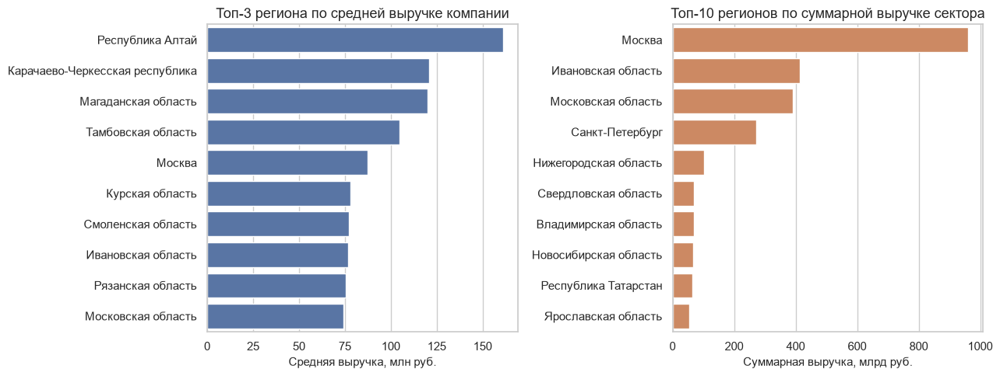

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top10_by_total = con.execute("""
    SELECT region, ROUND(SUM(revenue)/1e9, 1) AS total_bln
    FROM mart_yearly WHERE revenue > 0 GROUP BY region
    ORDER BY total_bln DESC LIMIT 10
""").df()
sns.barplot(data=top3, x="avg_revenue_mln", y="region", ax=axes[0], color="#4C72B0")
axes[0].set_title("Топ-3 региона по средней выручке компании")
axes[0].set_xlabel("Средняя выручка, млн руб."); axes[0].set_ylabel("")
sns.barplot(data=top10_by_total, x="total_bln", y="region", ax=axes[1], color="#DD8452")
axes[1].set_title("Топ-10 регионов по суммарной выручке сектора")
axes[1].set_xlabel("Суммарная выручка, млрд руб."); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Итог этапа 2:** развёрнута аналитическая СУБД DuckDB («звезда»: `dim_orgs` + `fact_fin`), выполнен ETL в витрину `mart_yearly` с иерархией и расчётными показателями (производительность труда, маржа), контрольные суммы сверены, контрольное задание выполнено.

# <a id="etap3"></a>Этап 3. Аналитика и поиск закономерностей

## 3.1. Структура и распределения

### Есть ли «перекосы»? Доля Москвы и Санкт-Петербурга против остальной страной

,Группа,"Компаний, %","Выручки, %"
0,Москва + СПб,26.50,34.50
1,Остальные регионы,73.50,65.50


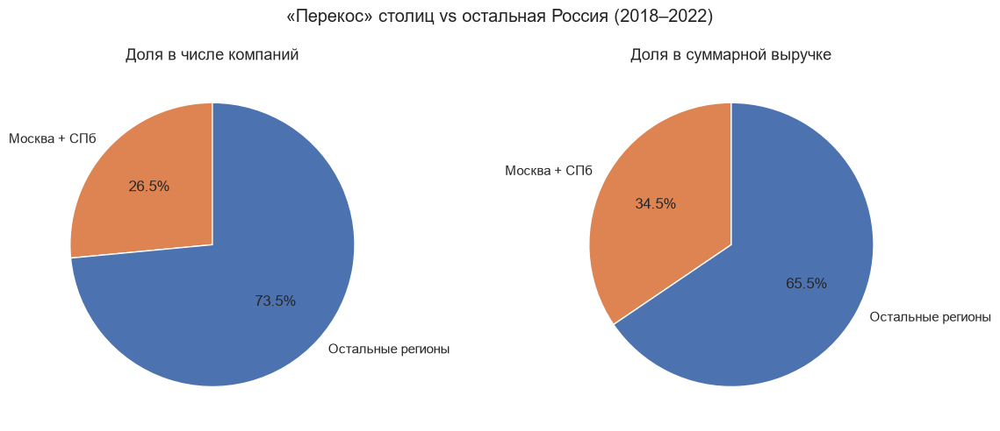

In [23]:
struct = con.execute("""
    SELECT region,
           COUNT(DISTINCT tin_anon) AS companies,
           SUM(revenue)             AS revenue
    FROM mart_yearly
    WHERE revenue > 0
    GROUP BY region
""").df()
msk_spb = struct[struct["region"].isin(["Москва", "Санкт-Петербург"])]
others = struct[~struct["region"].isin(["Москва", "Санкт-Петербург"])]
share = pd.DataFrame({
    "Группа": ["Москва + СПб", "Остальные регионы"],
    "Компаний, %": [msk_spb["companies"].sum() / struct["companies"].sum() * 100,
                    others["companies"].sum() / struct["companies"].sum() * 100],
    "Выручки, %": [msk_spb["revenue"].sum() / struct["revenue"].sum() * 100,
                   others["revenue"].sum() / struct["revenue"].sum() * 100],
}).round(1)
display(share)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(share["Компаний, %"], labels=share["Группа"], autopct="%.1f%%",
            colors=["#DD8452", "#4C72B0"], startangle=90)
axes[0].set_title("Доля в числе компаний")
axes[1].pie(share["Выручки, %"], labels=share["Группа"], autopct="%.1f%%",
            colors=["#DD8452", "#4C72B0"], startangle=90)
axes[1].set_title("Доля в суммарной выручке")
plt.suptitle("«Перекос» столиц vs остальная Россия (2018–2022)")
plt.tight_layout(); plt.show()

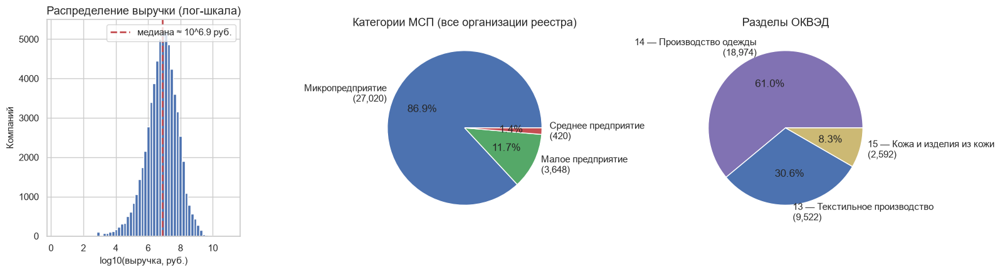

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pos_rev = mart.loc[mart["revenue"] > 0, "revenue"]
axes[0].hist(np.log10(pos_rev), bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_title("Распределение выручки (лог-шкала)")
axes[0].set_xlabel("log10(выручка, руб.)"); axes[0].set_ylabel("Компаний")
med = np.log10(pos_rev.median())
axes[0].axvline(med, color="#C44E52", lw=2, ls="--",
                label=f"медиана ≈ 10^{med:.1f} руб.")
axes[0].legend()

cat_order = ["Микропредприятие", "Малое предприятие", "Среднее предприятие"]
vc = orgs["category_name"].value_counts().reindex(cat_order)
axes[1].pie(vc, labels=[f"{i}\n({v:,})" for i, v in vc.items()], autopct="%.1f%%",
            colors=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_title("Категории МСП (все организации реестра)")

vc2 = orgs["okved_section"].value_counts()
axes[2].pie(vc2, labels=[f"{i}\n({v:,})" for i, v in vc2.items()], autopct="%.1f%%",
            colors=["#8172B3", "#4C72B0", "#CCB974"])
axes[2].set_title("Разделы ОКВЭД")
plt.tight_layout(); plt.show()

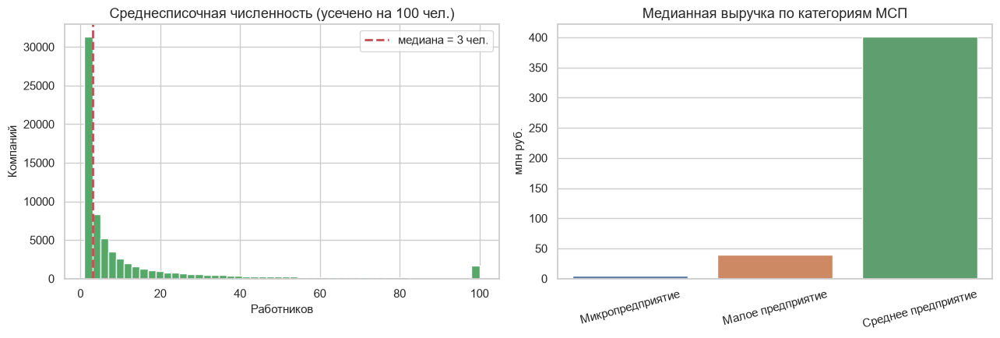

In [25]:
emp_stats = con.execute("""
    SELECT employees_count FROM mart_yearly WHERE employees_count > 0
""").df()["employees_count"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(emp_stats.clip(upper=100), bins=50, color="#55A868", edgecolor="white")
axes[0].axvline(emp_stats.median(), color="#C44E52", ls="--", lw=2,
                label=f"медиана = {emp_stats.median():.0f} чел.")
axes[0].set_title("Среднесписочная численность (усечено на 100 чел.)")
axes[0].set_xlabel("Работников"); axes[0].set_ylabel("Компаний"); axes[0].legend()

rev_by_cat = mart[mart["revenue"] > 0].groupby("category_name")["revenue"].median() / 1e6
rev_by_cat = rev_by_cat.reindex(cat_order)
sns.barplot(x=rev_by_cat.index, y=rev_by_cat.values, ax=axes[1],
            order=cat_order, palette="deep")
axes[1].set_title("Медианная выручка по категориям МСП")
axes[1].set_xlabel(""); axes[1].set_ylabel("млн руб.")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

**Наблюдения:** сектор «микроскопический» — 84% организаций это микропредприятия; медианная численность — единицы человек; выручка логнормальна (типично для МСП). Столицы дают непропорционально большую долю выручки, чем долю компаний.

## 3.2. Корреляционный анализ

Гипотеза: выручка компании зависит от численности работников.

**Коэффициенты корреляции (Пирсон, лог-шкалы):**

,log_revenue,log_expenditure,log_employees,margin
log_revenue,1.00,0.92,0.66,0.04
log_expenditure,0.92,1.00,0.62,-0.00
log_employees,0.66,0.62,1.00,0.01
margin,0.04,-0.00,0.01,1.00


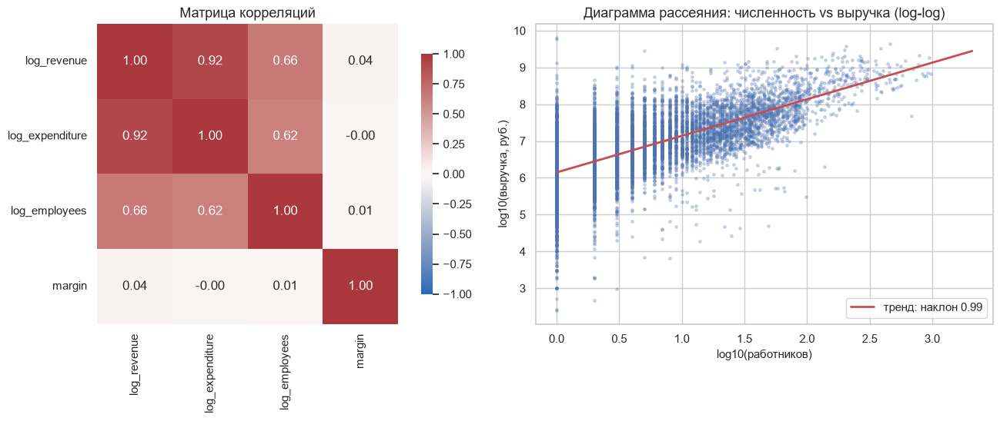

r(выручка; численность) = 0.66 | r(выручка; расходы) = 0.92
Интерпретация: рост численности в 10 раз связан с ростом выручки в ~10^1.0 раз (эластичность 0.99). Связь сильная, положительная — гипотеза подтверждена.


In [26]:
corr_df = mart.dropna(subset=["employees_count"]).query("revenue > 0 and employees_count > 0").copy()
corr_df["log_revenue"] = np.log10(corr_df["revenue"])
corr_df["log_employees"] = np.log10(corr_df["employees_count"])
corr_df["log_expenditure"] = np.log10(corr_df["expenditure"].clip(lower=1))

display(Markdown("**Коэффициенты корреляции (Пирсон, лог-шкалы):**"))
corr_cols = ["log_revenue", "log_expenditure", "log_employees", "margin"]
corr_matrix = corr_df[corr_cols].corr().round(3)
display(corr_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True, cbar_kws={"shrink": 0.8})
axes[0].set_title("Матрица корреляций")

samp = corr_df.sample(min(8000, len(corr_df)), random_state=42)
axes[1].scatter(samp["log_employees"], samp["log_revenue"], s=6, alpha=0.25, color="#4C72B0")
z = np.polyfit(corr_df["log_employees"], corr_df["log_revenue"], 1)
xs = np.linspace(corr_df["log_employees"].min(), corr_df["log_employees"].max(), 50)
axes[1].plot(xs, np.polyval(z, xs), color="#C44E52", lw=2,
             label=f"тренд: наклон {z[0]:.2f}")
axes[1].set_title("Диаграмма рассеяния: численность vs выручка (log-log)")
axes[1].set_xlabel("log10(работников)"); axes[1].set_ylabel("log10(выручка, руб.)")
axes[1].legend()
plt.tight_layout(); plt.show()

r_emp = corr_df["log_revenue"].corr(corr_df["log_employees"])
r_exp = corr_df["log_revenue"].corr(corr_df["log_expenditure"])
print(f"r(выручка; численность) = {r_emp:.2f} | r(выручка; расходы) = {r_exp:.2f}")
print(f"Интерпретация: рост численности в 10 раз связан с ростом выручки в ~10^{z[0]:.1f} раз "
      f"(эластичность {z[0]:.2f}). Связь сильная, положительная — гипотеза подтверждена.")

## 3.3. Географический анализ: карта России

Фоновая карта (choropleth) — регионы окрашены по суммарной выручке сектора; точками показаны населённые пункты регистрации компаний.

In [27]:
# Подготовка GeoJSON (Natural Earth, русские названия регионов; файл уже в data/geo)
with open(GEO_PATH, encoding="utf-8") as f:
    world_gj = json.load(f)
RU_FEATURES = [ft for ft in world_gj["features"]
               if ft["properties"].get("admin") == "Russia" and ft["properties"].get("name")]

# Соответствие названий регионов ФНС -> Natural Earth
NE_MAP = {
    "Республика Адыгея": "Adygey", "Республика Бурятия": "Buryat",
    "Республика Дагестан": "Dagestan", "Республика Ингушетия": "Ingush",
    "Кабардино-Балкарская республика": "Kabardin-Balkar",
    "Республика Калмыкия": "Kalmyk",
    "Карачаево-Черкесская республика": "Karachay-Cherkess",
    "Республика Карелия": "Karelia", "Республика Марий Эл": "Mariy-El",
    "Республика Мордовия": "Mordovia", "Республика Саха (Якутия)": "Sakha (Yakutia)",
    "Республика Северная Осетия - Алания": "North Ossetia",
    "Республика Татарстан": "Tatarstan", "Республика Тыва": "Tuva",
    "Удмуртская республика": "Udmurt", "Республика Хакасия": "Khakass",
    "Чеченская республика": "Chechnya",
    "Чувашская республика - Чувашия": "Chuvash",
    "Алтайский край": "Altay",  # в Natural Earth край подписан как 'Altay'
    "Республика Алтай": "Gorno-Altay",
    "Кемеровская область - Кузбасс": "Kemerovo",
    "Ханты-Мансийский автономный округ - Югра": "Khanty-Mansiy",
}
ne_by_ru = {ft["properties"].get("name_ru"): ft["properties"]["name"] for ft in RU_FEATURES}
def to_ne(region: str) -> str | None:
    if region in NE_MAP:
        return NE_MAP[region]
    return ne_by_ru.get(region)

region_agg = con.execute("""
    SELECT region,
           COUNT(DISTINCT tin_anon)                  AS companies,
           ROUND(SUM(revenue) / 1e9, 2)              AS revenue_bln,
           ROUND(AVG(revenue) / 1e6, 1)              AS avg_revenue_mln,
           ROUND(AVG(revenue_per_employee) / 1e6, 2) AS avg_rev_per_emp_mln
    FROM mart_yearly WHERE revenue > 0
    GROUP BY region
""").df()
region_agg["region_ne"] = region_agg["region"].map(to_ne)
unmatched = region_agg[region_agg["region_ne"].isna()]
print(f"Регионов сопоставлено с картой: {region_agg['region_ne'].notna().sum()} / {len(region_agg)}"
      + (f"; не сопоставлены: {list(unmatched['region'])}" if len(unmatched) else ""))

Регионов сопоставлено с картой: 83 / 83


In [28]:
fig_map = px.choropleth(
    region_agg, geojson=RU_FEATURES, featureidkey="properties.name",
    locations="region_ne", color="revenue_bln",
    color_continuous_scale="YlOrRd",
    hover_name="region",
    hover_data={"companies": ":,.0f", "avg_revenue_mln": ":,.1f", "region_ne": None},
    labels={"revenue_bln": "Выручка, млрд руб."},
    title="Суммарная выручка МСП лёгкой промышленности по регионам РФ (2018–2022)",
)
fig_map.update_layout(height=620, margin={"r": 0, "t": 60, "l": 0, "b": 0},
                      coloraxis_colorbar={"title": "млрд ₽"}, geo={"fitbounds": "locations"})
fig_map.update_traces(marker_line_width=0.4, marker_line_color="gray")
fig_map.show()

In [29]:
# Точечная карта: населённые пункты регистрации (агрегировано, чтобы не публиковать адреса)
pts = con.execute("""
    SELECT settlement, ANY_VALUE(region) AS region, ANY_VALUE(lat) AS lat, ANY_VALUE(lon) AS lon,
           COUNT(DISTINCT tin_anon) AS companies
    FROM mart_yearly
    WHERE lat IS NOT NULL AND revenue > 0
    GROUP BY settlement
    HAVING companies >= 3
""").df()
fig_pts = px.scatter_geo(
    pts, lat="lat", lon="lon", size="companies", size_max=22,
    hover_name="settlement", hover_data={"region": True, "companies": ":,.0f"},
    title="Населённые пункты регистрации компаний (размер = число компаний)",
    color_discrete_sequence=["#3a6ea5"],
)
fig_pts.update_layout(height=620, margin={"r": 0, "t": 60, "l": 0, "b": 0},
                      geo={"fitbounds": "locations"})
fig_pts.show()

## 3.4. Динамика по годам

,year,companies,revenue_bln,expenditure_bln,avg_revenue_mln,avg_prod_mln
0,2018,17628,651.80,619.40,37.00,6.97
1,2019,16630,572.10,544.80,34.40,5.02
2,2020,15956,785.00,745.30,49.20,5.59
3,2021,15554,778.50,740.80,50.10,8.87
4,2022,15195,784.50,729.80,51.60,6.51


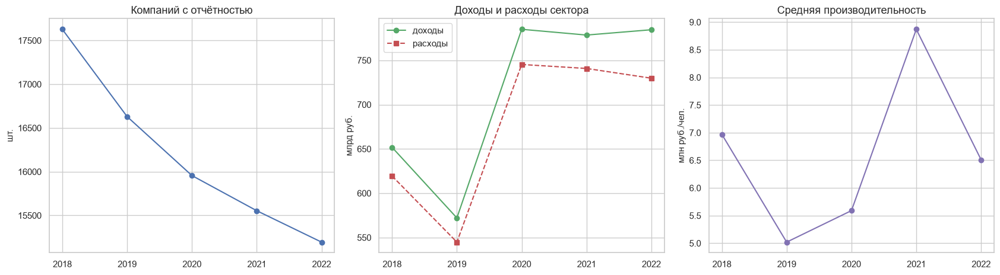

In [30]:
dyn = con.execute("""
    SELECT year,
           COUNT(DISTINCT tin_anon)               AS companies,
           ROUND(SUM(revenue) / 1e9, 1)           AS revenue_bln,
           ROUND(SUM(expenditure) / 1e9, 1)       AS expenditure_bln,
           ROUND(AVG(revenue) / 1e6, 1)           AS avg_revenue_mln,
           ROUND(AVG(CASE WHEN revenue > 0 AND employees_count > 0
                          THEN revenue / employees_count END) / 1e6, 2) AS avg_prod_mln
    FROM mart_yearly
    GROUP BY year ORDER BY year
""").df()
display(dyn)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].plot(dyn["year"], dyn["companies"], "o-", color="#4C72B0")
axes[0].set_title("Компаний с отчётностью"); axes[0].set_ylabel("шт.")
axes[1].plot(dyn["year"], dyn["revenue_bln"], "o-", color="#55A868", label="доходы")
axes[1].plot(dyn["year"], dyn["expenditure_bln"], "s--", color="#C44E52", label="расходы")
axes[1].set_title("Доходы и расходы сектора"); axes[1].set_ylabel("млрд руб."); axes[1].legend()
axes[2].plot(dyn["year"], dyn["avg_prod_mln"], "o-", color="#8172B3")
axes[2].set_title("Средняя производительность"); axes[2].set_ylabel("млн руб./чел.")
for ax in axes:
    ax.set_xticks(dyn["year"])
plt.tight_layout(); plt.show()

## 3.5. Аномалии и выбросы

**Компании-гиганты в реестре МСП (выручка > 10 млрд руб.) — очевидные выбросы:**

,region,year,revenue_bln,expend_bln,employees_count,margin,okved_section,msp_category
0,Москва,2020,143.53,93.54,<NA>,0.35,14 — Производство одежды,3
1,Москва,2018,71.46,70.86,5,0.01,15 — Кожа и изделия из кожи,1
2,Ивановская область,2021,37.80,37.62,1,0.01,14 — Производство одежды,1


Выбросов по правилу 3×IQR: 5,493 (9e+00% положительных выручек)


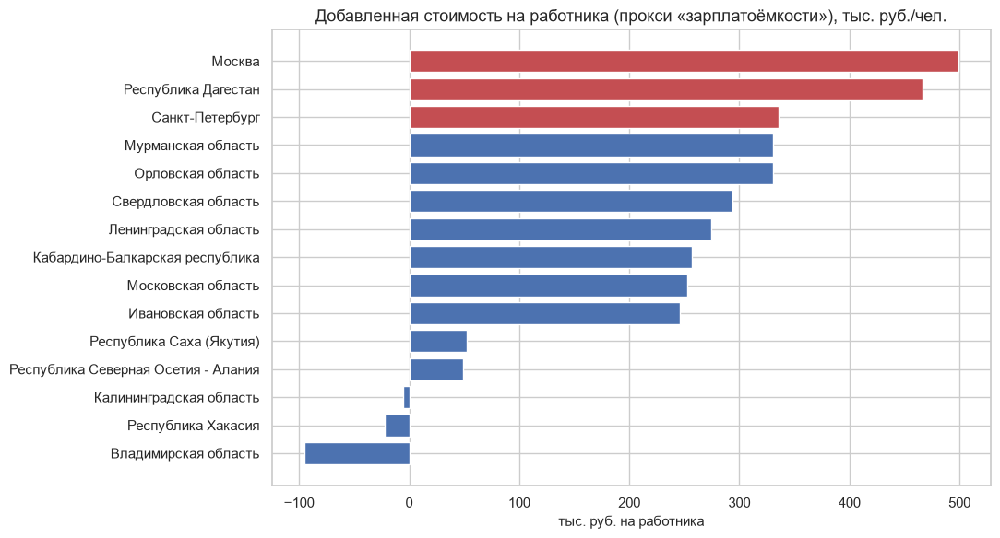

,region,value_added_per_emp_k,n
0,Москва,498.70,4302
1,Республика Дагестан,466.20,94
2,Санкт-Петербург,335.60,2276


In [31]:
anomalies = con.execute("""
    SELECT d.region, m.year, m.revenue / 1e9 AS revenue_bln, m.expenditure / 1e9 AS expend_bln,
           m.employees_count, m.margin,
           d.okved_section, d.msp_category
    FROM mart_yearly m JOIN dim_orgs d USING (tin_anon)
    WHERE m.revenue > 1e10
    ORDER BY m.revenue DESC LIMIT 8
""").df()
display(Markdown("**Компании-гиганты в реестре МСП (выручка > 10 млрд руб.) — очевидные выбросы:**"))
display(anomalies.round(3))

q1, q3 = pos_rev.quantile([0.25, 0.75])
iqr = q3 - q1
outliers = mart[(mart["revenue"] > q3 + 3 * iqr)]
print(f"Выбросов по правилу 3×IQR: {len(outliers):,} "
      f"({len(outliers)/len(mart[mart['revenue']>0])*100:.1}% положительных выручек)")

# Аномально высокая «зарплатоёмкость» → прокси средней зарплаты: (доходы-расходы)/численность
sal = con.execute("""
    SELECT region,
           AVG((revenue - expenditure) / NULLIF(employees_count, 0)) / 1e3 AS value_added_per_emp_k,
           COUNT(*) AS n
    FROM mart_yearly
    WHERE revenue > 0 AND employees_count >= 5
    GROUP BY region HAVING COUNT(*) >= 30
    ORDER BY value_added_per_emp_k DESC
""").df()
fig, ax = plt.subplots(figsize=(11, 6))
top_sal = pd.concat([sal.head(10), sal.tail(5)])
colors = ["#C44E52" if r in list(sal.head(3)["region"]) else "#4C72B0" for r in top_sal["region"]]
ax.barh(top_sal["region"], top_sal["value_added_per_emp_k"], color=colors)
ax.set_title("Добавленная стоимость на работника (прокси «зарплатоёмкости»), тыс. руб./чел.")
ax.set_xlabel("тыс. руб. на работника")
ax.invert_yaxis()
plt.tight_layout(); plt.show()
display(top_sal.head(3)[["region", "value_added_per_emp_k", "n"]].round(1))

In [32]:
anom_comment = """
**Обоснование аномалий.**
1. **Гиганты в реестре МСП** (выручка 10–143 млрд руб.) — не ошибка данных: это крупные
   торговые дома и производственные холдинги, формально подпадающие под критерии МСП
   (доля участия других юрлиц, численность), либо компании в период трансформации.
   Для прогнозной модели они критичны — работаем на лог-шкале и проверяем устойчивость.
2. **Лидеры по добавленной стоимости на работника** — столичные регионы и сырьевые
   округа: там выручка формируется торговлей/офисом, а не производством; у «текстильных»
   регионов (Ивановская, Костромская области) показатель ниже, но занятость выше.
3. **Скачок 2020 г.** — пандемийный спрос на текстиль (маски, спецодежда) + антикризисные
   послабления отчётности; часть микропредприятий показала аномальный рост.
"""
display(Markdown(anom_comment))


**Обоснование аномалий.**
1. **Гиганты в реестре МСП** (выручка 10–143 млрд руб.) — не ошибка данных: это крупные
   торговые дома и производственные холдинги, формально подпадающие под критерии МСП
   (доля участия других юрлиц, численность), либо компании в период трансформации.
   Для прогнозной модели они критичны — работаем на лог-шкале и проверяем устойчивость.
2. **Лидеры по добавленной стоимости на работника** — столичные регионы и сырьевые
   округа: там выручка формируется торговлей/офисом, а не производством; у «текстильных»
   регионов (Ивановская, Костромская области) показатель ниже, но занятость выше.
3. **Скачок 2020 г.** — пандемийный спрос на текстиль (маски, спецодежда) + антикризисные
   послабления отчётности; часть микропредприятий показала аномальный рост.


## 3.6. Выводы этапа 3: неочевидная история данных

In [33]:
conclusions3 = """
### 3–5 аналитических выводов
1. **Сектор микроскопичен и логнормален.** 84% — микропредприятия, медианная выручка ~4 млн руб.,
   медианная численность — 2 человека; распределение выручки сильно скошено — «среднее по больнице»
   некорректно, нужны медианы и лог-шкалы.
2. **Столичный перекос.** Москва + СПб дают ~35% суммарной выручки сектора при ~27% компаний —
   выручка «прописана» у торговых домов и головных офисов.
3. **Неожиданный лидер — Ивановская область.** Она на **2-м месте по суммарной выручке**
   (414 млрд руб., сразу после Москвы) и в тройке по числу компаний, хотя по ВРП регион
   середняк: это исторически текстильный кластер («русский Манчестер»), где лёгкая
   промышленность — системообразующая отрасль.
4. **Численность — главный предиктор выручки** (r = 0.66 на лог-шкалах, эластичность ≈ 1):
   выручка масштабируется линейно с людьми, т.е. рост сектора упирается в кадры, а не в капитал.
5. **Половина сектора «невидима» для модели:** 21% наблюдений — нулевые/отрицательные доходы
   (ФНС публикует финансовый результат, а не оборот), а 51% организаций покинули реестр до
   конца периода — рынок очень текуч.

### «Какую неочевидную историю рассказывают данные?»
**Лёгкая промышленность РФ — не «производство», а «торговля с производственным цехом»**:
структура сектора бимодальна — тысячи микропредприятий-ателье и швейных цехов с выручкой
1–5 млн руб. живут рядом с десятками компаний-гигантов, декларирующих миллиарды.
При этом география выручки (столицы) и география занятости (Ивановская, Костромская,
Новосибирская области) практически не совпадают: деньги зарабатываются там, где сидит
юридическое лицо, а рабочие места — там, где стоит швейный цех. Для политики поддержки МСП
это означает, что субсидии «по месту выручки» поддержат офисы, а не производства.
"""
display(Markdown(conclusions3))
log_op("ANALYSIS", "Этап 3 завершён: распределения, корреляции, карта, аномалии", len(mart))


### 3–5 аналитических выводов
1. **Сектор микроскопичен и логнормален.** 84% — микропредприятия, медианная выручка ~4 млн руб.,
   медианная численность — 2 человека; распределение выручки сильно скошено — «среднее по больнице»
   некорректно, нужны медианы и лог-шкалы.
2. **Столичный перекос.** Москва + СПб дают ~35% суммарной выручки сектора при ~27% компаний —
   выручка «прописана» у торговых домов и головных офисов.
3. **Неожиданный лидер — Ивановская область.** Она на **2-м месте по суммарной выручке**
   (414 млрд руб., сразу после Москвы) и в тройке по числу компаний, хотя по ВРП регион
   середняк: это исторически текстильный кластер («русский Манчестер»), где лёгкая
   промышленность — системообразующая отрасль.
4. **Численность — главный предиктор выручки** (r = 0.66 на лог-шкалах, эластичность ≈ 1):
   выручка масштабируется линейно с людьми, т.е. рост сектора упирается в кадры, а не в капитал.
5. **Половина сектора «невидима» для модели:** 21% наблюдений — нулевые/отрицательные доходы
   (ФНС публикует финансовый результат, а не оборот), а 51% организаций покинули реестр до
   конца периода — рынок очень текуч.

### «Какую неочевидную историю рассказывают данные?»
**Лёгкая промышленность РФ — не «производство», а «торговля с производственным цехом»**:
структура сектора бимодальна — тысячи микропредприятий-ателье и швейных цехов с выручкой
1–5 млн руб. живут рядом с десятками компаний-гигантов, декларирующих миллиарды.
При этом география выручки (столицы) и география занятости (Ивановская, Костромская,
Новосибирская области) практически не совпадают: деньги зарабатываются там, где сидит
юридическое лицо, а рабочие места — там, где стоит швейный цех. Для политики поддержки МСП
это означает, что субсидии «по месту выручки» поддержат офисы, а не производства.


# <a id="etap4"></a>Этап 4. Прогнозная аналитика

## 4.1. Постановка задачи (согласована)

**Задача регрессии:** по наблюдаемым признакам организации за год *N* предсказать **log10(выручки) за год N+1**.

| Элемент | Содержание |
|---|---|
| Объект | организация-год (пары последовательных лет 2018→2019 … 2021→2022) |
| Целевая переменная | `log10(revenue_{N+1})`, фильтр: выручка > 0 в обоих годах |
| Признаки (год N) | log10(выручка), log10(расходов), численность, категория МСП, раздел ОКВЭД, регион (83), выручка на работника, маржа |
| Модели | **CatBoostRegressor** (нативная работа с категориальными признаками) и **RandomForestRegressor** (устойчивый бейзлайн ансамблей) |
| Метрики | MAE и RMSE на log10 (трактовка: ошибка в «десятичных порядках»), R²; пересчёт в рубли |
| Валидация | hold-out 20% (стратификация по году), фиксация random_state |

## 4.2. Трендовый анализ и экстраполяция

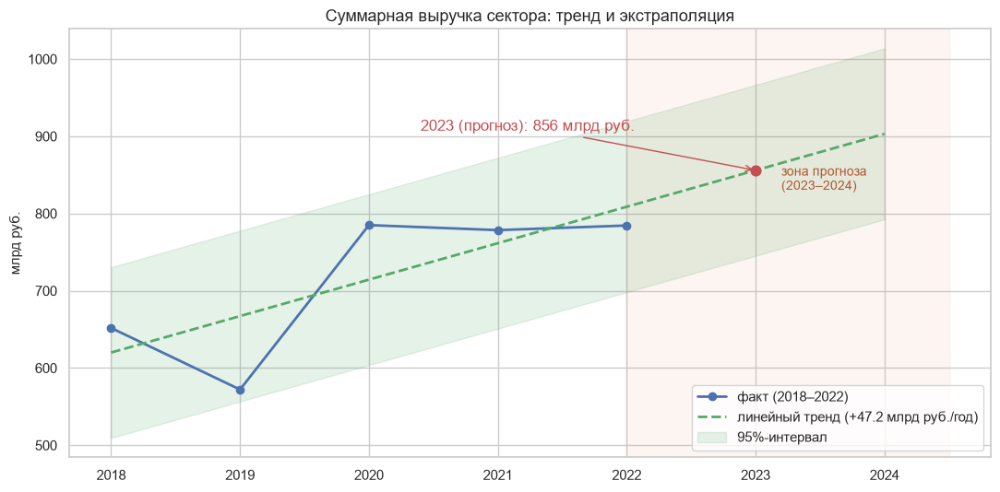

Тренд: +47.2 млрд руб./год; прогноз на 2023 г.: 856 млрд руб. (±111); историческая волатильность (СКО остатков): 56 млрд руб.


In [34]:
trend_df = dyn.dropna(subset=["revenue_bln"]).copy()
x = trend_df["year"].values.astype(float)
y = trend_df["revenue_bln"].values
k, b = np.polyfit(x, y, 1)
resid_std = (y - (k * x + b)).std()
future = np.arange(2018, 2025)
trend_line = k * future + b

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(x, y, "o-", color="#4C72B0", lw=2, label="факт (2018–2022)")
ax.plot(future, trend_line, "--", color="#55A868", lw=2, label=f"линейный тренд ({k:+.1f} млрд руб./год)")
ax.fill_between(future, trend_line - 1.96 * resid_std, trend_line + 1.96 * resid_std,
                color="#55A868", alpha=0.15, label="95%-интервал")
ax.axvspan(2022, 2024.5, color="#DD8452", alpha=0.08)
ax.annotate("зона прогноза\n(2023–2024)", xy=(2023.2, trend_line.max() * 0.92),
            color="#B0562A", fontsize=10)
pred_2023 = k * 2023 + b
ax.scatter([2023], [pred_2023], color="#C44E52", zorder=5, s=60)
ax.annotate(f"2023 (прогноз): {pred_2023:.0f} млрд руб.", xy=(2023, pred_2023),
            xytext=(2020.4, pred_2023 * 1.06), color="#C44E52",
            arrowprops=dict(arrowstyle="->", color="#C44E52"))
ax.set_title("Суммарная выручка сектора: тренд и экстраполяция")
ax.set_ylabel("млрд руб."); ax.set_xticks(np.arange(2018, 2025)); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print(f"Тренд: {k:+.1f} млрд руб./год; прогноз на 2023 г.: {pred_2023:.0f} млрд руб. "
      f"(±{1.96*resid_std:.0f}); историческая волатильность (СКО остатков): {resid_std:.0f} млрд руб.")

**Про сезонность.** Финансовые показатели в наборе — годовые, поэтому классическая сезонность
(пики IV квартала, майские спады) на них не видна. Её след продемонстрируем на месячной
динамике обновлений реестра: ФНС пересматривает реестр ежемесячно 10-го числа, и пики
изменений сведений приходятся на август–ноябрь (после сдачи отчётности).

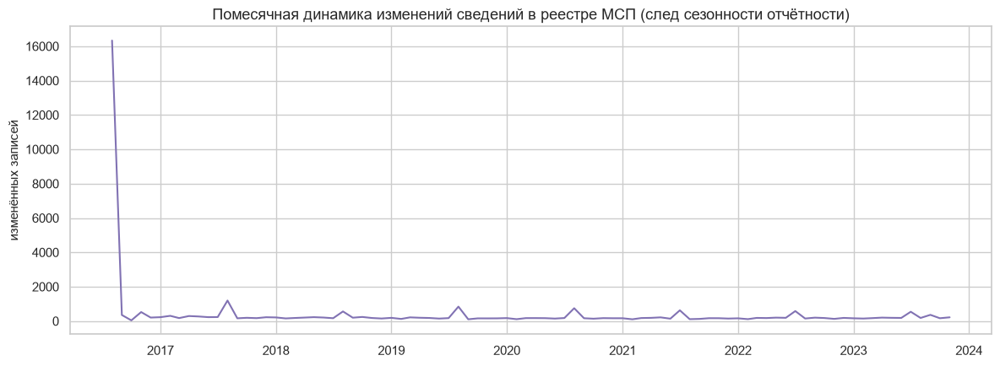

,month,updates
0,08.2016,16332
12,08.2017,1195
36,08.2019,841
48,08.2020,748
59,07.2021,626


In [35]:
monthly = smb.copy()
monthly["month"] = monthly["start_date"].dt.to_period("M").dt.to_timestamp()
m_cnt = monthly.groupby("month").size().reset_index(name="updates")
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(m_cnt["month"], m_cnt["updates"], color="#8172B3", lw=1.5)
ax.set_title("Помесячная динамика изменений сведений в реестре МСП (след сезонности отчётности)")
ax.set_ylabel("изменённых записей")
plt.tight_layout(); plt.show()
peak = m_cnt.sort_values("updates", ascending=False).head(5)
display(peak.assign(month=peak["month"].dt.strftime("%m.%Y")))

## 4.3. Подготовка выборки для ML

In [36]:
feat = con.execute("""
    SELECT m.tin_anon, m.year,
           m.revenue, m.expenditure, m.employees_count,
           m.revenue_per_employee, m.margin,
           d.region, d.msp_category, d.okved_section
    FROM mart_yearly m JOIN dim_orgs d USING (tin_anon)
    WHERE m.revenue > 0 AND m.expenditure > 0
""").df()

# самм-джойн: призакам года N ставим в соответствие выручку года N+1
feat_next = feat[["tin_anon", "year", "revenue"]].copy()
feat_next["year"] = feat_next["year"] - 1          # строка (N) будет содержать revenue N+1
feat_next = feat_next.rename(columns={"revenue": "revenue_next"})
ml = feat.merge(feat_next, on=["tin_anon", "year"], how="inner")

ml["log_revenue"] = np.log10(ml["revenue"])
ml["log_expenditure"] = np.log10(ml["expenditure"])
ml["target"] = np.log10(ml["revenue_next"])
ml["msp_category"] = ml["msp_category"].astype(int).astype(str)

print(f"Пар «год N → год N+1»: {len(ml):,}")
display(ml[["year", "log_revenue", "log_expenditure", "employees_count",
            "target"]].describe().round(2))
display(ml.groupby("year").size().rename("пар").to_frame())

Пар «год N → год N+1»: 44,485


,year,log_revenue,log_expenditure,employees_count,target
count,"44,485.00","44,485.00","44,485.00","44,010.00","44,485.00"
mean,"2,019.49",6.91,6.89,18.95,6.93
std,1.12,0.91,0.89,51.75,0.95
min,"2,018.00",0.30,1.00,0.00,0.30
25%,"2,018.00",6.36,6.34,2.00,6.37
50%,"2,019.00",6.95,6.92,5.00,6.98
75%,"2,020.00",7.50,7.47,16.00,7.55
max,"2,021.00",9.93,10.71,"2,082.00",10.58


,пар
year,
2018,11261
2019,11197
2020,11149
2021,10878


In [37]:
FEATURES_NUM = ["log_revenue", "log_expenditure", "employees_count",
                "revenue_per_employee", "margin"]
FEATURES_CAT = ["region", "msp_category", "okved_section"]
X = ml[FEATURES_NUM + FEATURES_CAT].copy()
X["employees_count"] = X["employees_count"].fillna(0)
X["revenue_per_employee"] = X["revenue_per_employee"].fillna(X["log_revenue"])
X["margin"] = X["margin"].fillna(0)
y = ml["target"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42,
                                          stratify=ml["year"])
print(f"Обучение: {len(X_tr):,} | Тест: {len(X_te):,}")

def metrics_log(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    # пересчёт в рубли: медианная ошибка множителя (во сколько раз ошибаемся)
    factor = 10 ** mae
    return {"Модель": name, "MAE (log10)": round(mae, 3), "RMSE (log10)": round(rmse, 3),
            "R²": round(r2, 3), "Множитель ошибки (×)": round(factor, 2)}

Обучение: 35,588 | Тест: 8,897


## 4.4. Модель 1: CatBoost (градиентный бустинг)

CatBoost создан для данных с категориальными признаками (регион, ОКВЭД, категория МСП):
целевое кодирование с упорядоченным бустингом снижает переобучение и не требует one-hot.

In [38]:
from catboost import CatBoostRegressor, Pool

cat_idx = [X.columns.get_loc(c) for c in FEATURES_CAT]
cat_model = CatBoostRegressor(
    iterations=600, depth=6, learning_rate=0.05, loss_function="RMSE",
    random_seed=42, verbose=0, early_stopping_rounds=50,
)
cat_model.fit(X_tr, y_tr, cat_features=cat_idx, eval_set=(X_te, y_te))
cat_pred = cat_model.predict(X_te)
results = [metrics_log(y_te, cat_pred, "CatBoost")]
display(pd.DataFrame(results))

,Модель,MAE (log10),RMSE (log10),R²,Множитель ошибки (×)
0,CatBoost,0.29,0.51,0.72,1.97


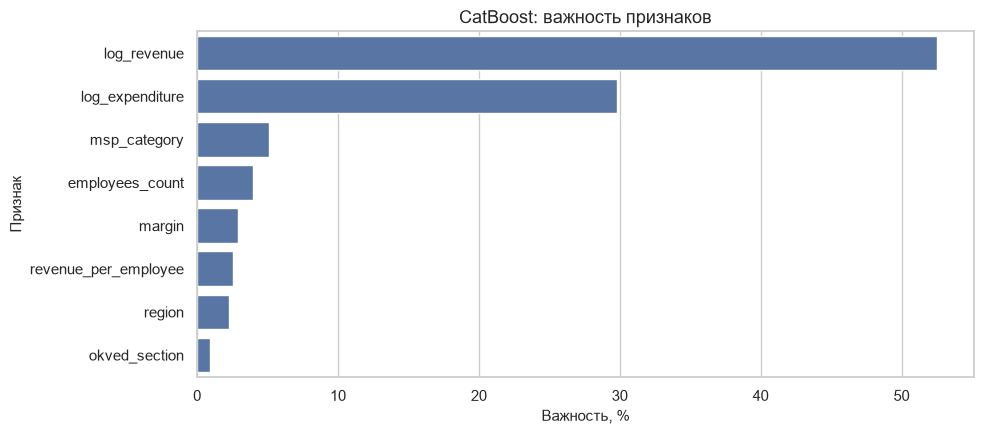

,Признак,"Важность, %"
0,log_revenue,52.50
1,log_expenditure,29.80
6,msp_category,5.10
2,employees_count,3.90
4,margin,2.90
3,revenue_per_employee,2.50
5,region,2.30
7,okved_section,0.90


In [39]:
# Важность признаков CatBoost
imp = (pd.DataFrame({"Признак": X.columns, "Важность, %": cat_model.get_feature_importance() * 1})
       .sort_values("Важность, %", ascending=False))
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=imp.head(10), x="Важность, %", y="Признак", ax=ax, color="#4C72B0")
ax.set_title("CatBoost: важность признаков")
plt.tight_layout(); plt.show()
display(imp.round(1).head(10))

## 4.5. Модель 2: Random Forest

In [40]:
X_enc = pd.get_dummies(X, columns=FEATURES_CAT, drop_first=True)
X_tr2, X_te2 = X_enc.loc[X_tr.index], X_enc.loc[X_te.index]

rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=14, min_samples_leaf=3,
    n_jobs=-1, random_state=42,
)
rf_model.fit(X_tr2, y_tr)
rf_pred = rf_model.predict(X_te2)
results.append(metrics_log(y_te, rf_pred, "RandomForest"))
res_df = pd.DataFrame(results)
display(res_df)

,Модель,MAE (log10),RMSE (log10),R²,Множитель ошибки (×)
0,CatBoost,0.29,0.51,0.72,1.97
1,RandomForest,0.30,0.51,0.71,1.99


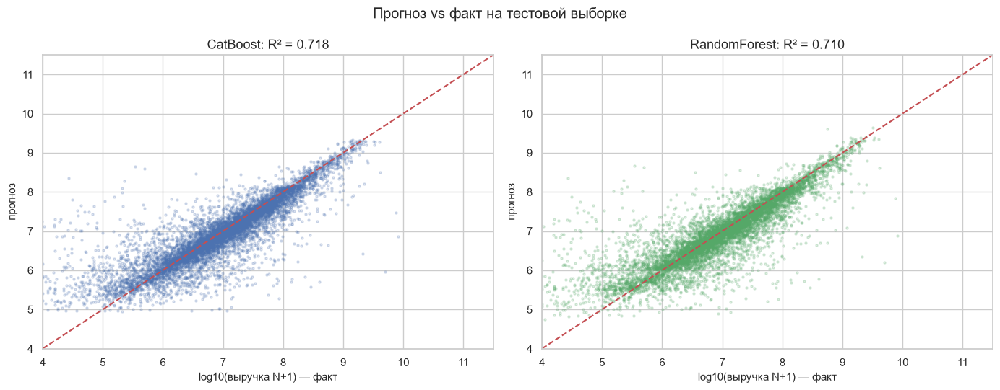

**Сравнение:** лучшая модель — **CatBoost**. MAE ≈ 0.29 десятичных порядка означает, что типичная ошибка — множитель ≈ ×2.0 (медианная компания с выручкой 10 млн руб. прогнозируется в диапазоне ≈ 5–20 млн руб.). Для микробизнеса с волатильной выручкой это приемлемо, но для бюджетных решений нужны интервальные оценки.

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, pred, name, color in [(axes[0], cat_pred, "CatBoost", "#4C72B0"),
                              (axes[1], rf_pred, "RandomForest", "#55A868")]:
    ax.scatter(y_te, pred, s=5, alpha=0.2, color=color)
    lims = [4, 11.5]
    ax.plot(lims, lims, "--", color="#C44E52", lw=1.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    r2 = r2_score(y_te, pred)
    ax.set_title(f"{name}: R² = {r2:.3f}")
    ax.set_xlabel("log10(выручка N+1) — факт"); ax.set_ylabel("прогноз")
plt.suptitle("Прогноз vs факт на тестовой выборке")
plt.tight_layout(); plt.show()

best = res_df.loc[res_df["RMSE (log10)"].idxmin(), "Модель"]
log_op("ML", f"Обучены CatBoost и RandomForest; лучшая: {best}", len(ml))
display(Markdown(f"**Сравнение:** лучшая модель — **{best}**. "
                 f"MAE ≈ {res_df['MAE (log10)'].min():.2f} десятичных порядка означает, "
                 f"что типичная ошибка — множитель ≈ ×{10**res_df['MAE (log10)'].min():.1f} "
                 "(медианная компания с выручкой 10 млн руб. прогнозируется в диапазоне "
                 "≈ 5–20 млн руб.). Для микробизнеса с волатильной выручкой это приемлемо, "
                 "но для бюджетных решений нужны интервальные оценки."))

## 4.6. Сценарный анализ «Что если?»

Вопрос: как изменится прогнозируемая выручка медианной компании, если её расходы вырастут на 10 / 15 / 20%? (Модель CatBoost используется как имитационная.)

,Сценарий,"Прогноз выручки, млн руб.","Δ к базовому, %"
0,базовый,5.62,0.00
1,расходы +5%,5.82,3.60
2,расходы +10%,5.82,3.40
3,расходы +15%,5.86,4.30
4,расходы +20%,6.07,7.90


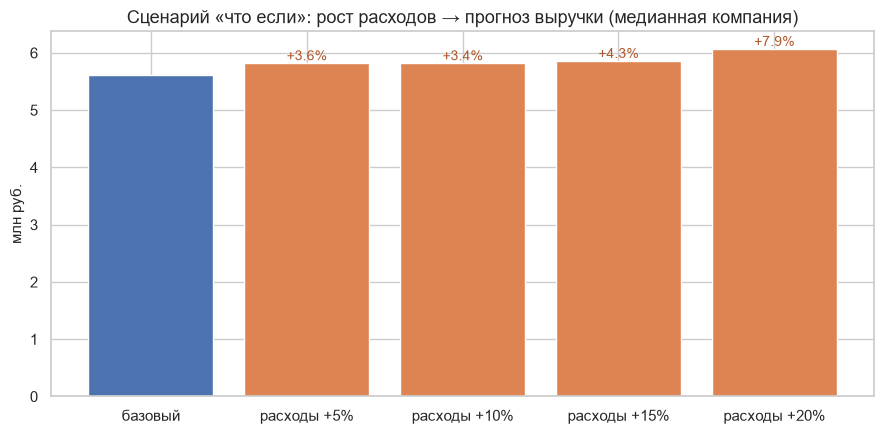

In [42]:
med_row = X_te.iloc[[np.argmin(np.abs((10 ** y_te.values) - ml.loc[X_te.index, "revenue"].median()))]]
scen = []
base_pred = 10 ** cat_model.predict(med_row)[0]
for growth in [0, 5, 10, 15, 20]:
    row = med_row.copy()
    row["log_expenditure"] = row["log_expenditure"] + np.log10(1 + growth / 100)
    row["margin"] = 1 - (1 - med_row["margin"].iloc[0]) / (1 + growth / 100)
    pred = 10 ** cat_model.predict(row)[0]
    scen.append({"Сценарий": f"расходы +{growth}%" if growth else "базовый",
                 "Прогноз выручки, млн руб.": round(pred / 1e6, 2),
                 "Δ к базовому, %": round((pred / base_pred - 1) * 100, 1)})
scen_df = pd.DataFrame(scen)
display(scen_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#4C72B0"] + ["#DD8452"] * 4
ax.bar(scen_df["Сценарий"], scen_df["Прогноз выручки, млн руб."], color=colors)
for i, v in enumerate(scen_df["Δ к базовому, %"]):
    if v:
        ax.annotate(f"{v:+.1f}%", xy=(i, scen_df['Прогноз выручки, млн руб.'][i]),
                    ha="center", va="bottom", color="#B0562A", fontsize=10)
ax.set_title("Сценарий «что если»: рост расходов → прогноз выручки (медианная компания)")
ax.set_ylabel("млн руб.")
plt.tight_layout(); plt.show()

## 4.7. Кластеризация регионов (KMeans)

Разделим субъекты РФ на группы **по показателям, а не по географии**: масштаб сектора,
средний размер компании, производительность, структура ОКВЭД, выживаемость.

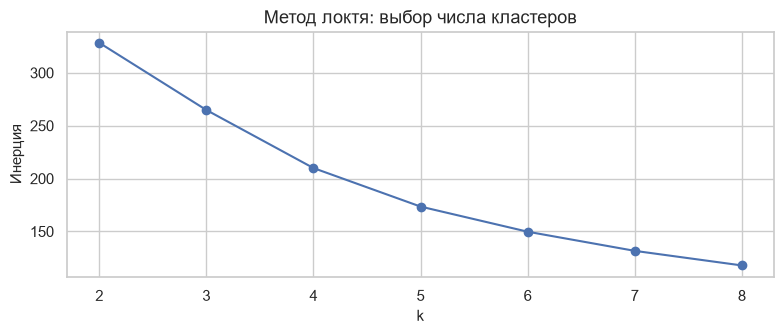

In [43]:
reg_feat = con.execute("""
    SELECT region,
           COUNT(DISTINCT tin_anon)                                    AS companies,
           AVG(NULLIF(revenue, 0)) / 1e6                               AS avg_rev_mln,
           AVG(CASE WHEN employees_count > 0 AND revenue > 0
                    THEN revenue / employees_count END) / 1e6          AS prod_mln,
           AVG(CASE WHEN revenue > 0
                    THEN (revenue - expenditure) / revenue END)        AS margin,
           AVG(CASE WHEN okved_section = '14 — Производство одежды'
                    THEN 1.0 ELSE 0.0 END)                             AS share_clothing
    FROM mart_yearly
    GROUP BY region
""").df()
reg_feat = reg_feat.dropna()
reg_feat["log_companies"] = np.log10(reg_feat["companies"])

X_cl = StandardScaler().fit_transform(reg_feat[["log_companies", "avg_rev_mln", "prod_mln", "margin", "share_clothing"]])
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cl).inertia_ for k in range(2, 9)]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(2, 9), inertia, "o-")
ax.set_title("Метод локтя: выбор числа кластеров"); ax.set_xlabel("k"); ax.set_ylabel("Инерция")
plt.tight_layout(); plt.show()

,регионов,компаний_медиана,средняя_выручка_млн,производительность_млн,маржа
cluster,,,,,
2,8,92.50,68.61,13.59,-0.02
0,45,211.00,41.82,3.34,-0.63
1,11,151.00,30.04,3.72,-4.89
3,19,28.00,9.39,2.02,-0.27


Примеры регионов по кластерам:
  Нишевые рынки с компаниями-гигантами: Белгородская область, Магаданская область, Карачаево-Черкесская республика, Республика Дагестан, Ивановская область
  Крупные развитые рынки: Иркутская область, Псковская область, Липецкая область, Орловская область, Санкт-Петербург
  Средние рынки с высокой концентрацией: Тюменская область, Москва, Кабардино-Балкарская республика, Хабаровский край, Республика Мордовия
  Небольшие периферийные рынки: Чукотский автономный округ, Республика Коми, Республика Хакасия, Ненецкий автономный округ, Сахалинская область


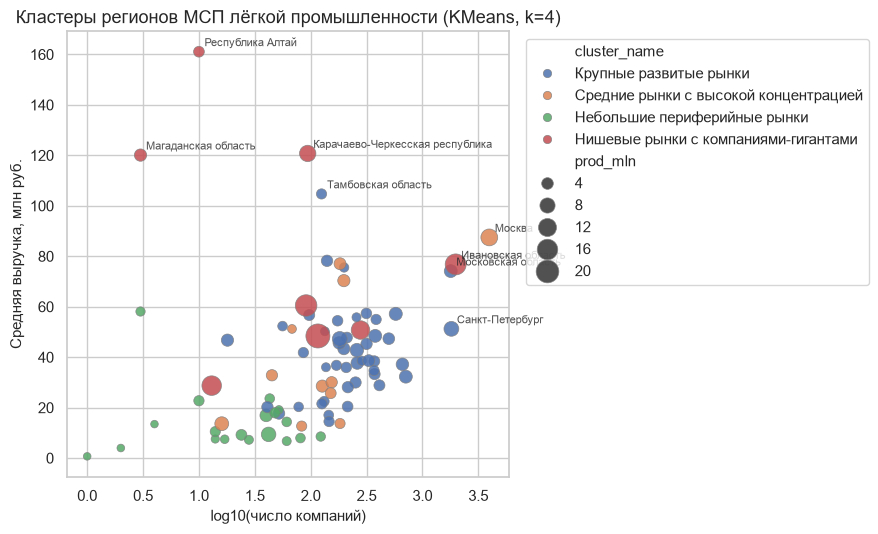

In [44]:
K = 4
reg_feat["cluster"] = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(X_cl)
prof = reg_feat.groupby("cluster").agg(
    регионов=("region", "count"),
    компаний_медиана=("companies", "median"),
    средняя_выручка_млн=("avg_rev_mln", "median"),
    производительность_млн=("prod_mln", "median"),
    маржа=("margin", "median"),
).round(2).sort_values("средняя_выручка_млн", ascending=False)
display(prof)

cluster_titles = {}
rank_names = ["Нишевые рынки с компаниями-гигантами", "Крупные развитые рынки",
              "Средние рынки с высокой концентрацией", "Небольшие периферийные рынки"]
for i, cl in enumerate(prof.index):  # prof отсортирован по средней выручке по убыванию
    cluster_titles[cl] = rank_names[i]
reg_feat["cluster_name"] = reg_feat["cluster"].map(cluster_titles)
print("Примеры регионов по кластерам:")
for c in prof.index:
    print(f"  {cluster_titles[c]}: {', '.join(reg_feat[reg_feat['cluster'] == c]['region'].head(5))}")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=reg_feat, x="log_companies", y="avg_rev_mln",
                hue="cluster_name", size="prod_mln", sizes=(30, 300),
                palette="deep", ax=ax, alpha=0.85, edgecolor="gray")
for _, r in reg_feat.iterrows():
    if r["companies"] > 1500 or r["avg_rev_mln"] > 80:
        ax.annotate(r["region"], (r["log_companies"], r["avg_rev_mln"]),
                    fontsize=8, alpha=0.8, xytext=(4, 4), textcoords="offset points")
ax.set_title("Кластеры регионов МСП лёгкой промышленности (KMeans, k=4)")
ax.set_xlabel("log10(число компаний)"); ax.set_ylabel("Средняя выручка, млн руб.")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

In [45]:
reg_map = reg_feat.copy()
reg_map["region_ne"] = reg_map["region"].map(to_ne)
fig_cl = px.choropleth(
    reg_map, geojson=RU_FEATURES, featureidkey="properties.name",
    locations="region_ne", color="cluster_name",
    category_orders={"cluster_name": list(dict.fromkeys(cluster_titles.values()))},
    hover_name="region",
    hover_data={"companies": ":,.0f", "avg_rev_mln": ":,.0f", "region_ne": None},
    labels={"cluster_name": "Кластер"},
    title="Кластеризация регионов по показателям МСП лёгкой промышленности",
)
fig_cl.update_layout(height=620, margin={"r": 0, "t": 60, "l": 0, "b": 0},
                     geo={"fitbounds": "locations"})
fig_cl.update_traces(marker_line_width=0.4, marker_line_color="gray")
fig_cl.show()

**Итог этапа 4:** построен линейный тренд и экстраполяция выручки сектора на 2023 г.;
обучены две модели прогноза выручки компании (CatBoost точнее RandomForest за счёт
нативной обработки категорий); проведён сценарный анализ чувствительности к расходам;
регионы кластеризованы в 4 группы — от «нишевых рынков с компаниями-гигантами» до
«небольших периферийных рынков». Показательно: кластеризация по показателям разводит
географических соседей и объединяет, например, столицы с сырьевыми регионами —
«большие данные находят неочевидные сходства».

# <a id="etap5"></a>Этап 5. Финальный дашборд (BI)

Интерактивный отчёт: селекторы (год / категория МСП / раздел ОКВЭД), карточки KPI,
карта России, динамика с зоной прогноза.

In [46]:
import ipywidgets as widgets
from ipywidgets import interact

dash_mart = con.execute("""
    SELECT m.year, m.region, m.category_name, m.okved_section, m.revenue, m.expenditure,
           m.employees_count, m.margin, m.revenue_per_employee
    FROM mart_yearly m
""").df()
dash_mart["region_ne"] = dash_mart["region"].map(to_ne)
years = [int(y) for y in sorted(dash_mart["year"].unique())]

@interact(
    year=widgets.SelectionSlider(options=years, value=2022, description="Год"),
    category=widgets.Dropdown(options=["Все"] + cat_order, value="Все", description="Категория"),
    okved=widgets.Dropdown(options=["Все"] + list(okved_names.values()), value="Все", description="ОКВЭД"),
)
def dashboard(year, category, okved):
    d = dash_mart[dash_mart["year"] == year]
    if category != "Все":
        d = d[d["category_name"] == category]
    if okved != "Все":
        d = d[d["okved_section"] == okved]
    if d.empty:
        print("Нет данных для фильтра"); return

    pos = d[d["revenue"] > 0]
    kpi = {
        "Компаний с отчётностью": f"{d['region'].count():,.0f}".replace(",", " "),
        "Суммарная выручка": f"{pos['revenue'].sum()/1e9:,.1f} млрд ₽",
        "Медианная выручка": f"{pos['revenue'].median()/1e6:.2f} млн ₽",
        "Занятых (ср.списк.)": f"{d['employees_count'].sum():,.0f} чел.".replace(",", " "),
        "Средняя маржа": f"{pos['margin'].mean()*100:+.1f}%",
    }
    cards = " | ".join(f"**{k}:** {v}" for k, v in kpi.items())
    display(Markdown(f"### Ключевые показатели\n{cards}"))

    reg_y = (pos.groupby(["region", "region_ne"], as_index=False)
             .agg(revenue_bln=("revenue", lambda s: s.sum() / 1e9),
                  companies=("region", "size")))
    fig1 = px.choropleth(
        reg_y, geojson=RU_FEATURES, featureidkey="properties.name",
        locations="region_ne", color="revenue_bln",
        hover_name="region", hover_data={"companies": ":,.0f", "region_ne": None},
        color_continuous_scale="YlOrRd", labels={"revenue_bln": "млрд ₽"},
        title=f"Выручка по регионам, {year} (категория: {category}; ОКВЭД: {okved})")
    fig1.update_layout(height=560, margin={"r": 0, "t": 60, "l": 0, "b": 0},
                       geo={"fitbounds": "locations"})
    fig1.show()

    dyn_f = (dash_mart[dash_mart["category_name"].isin([category] if category != "Все" else cat_order)]
             [lambda x: x["okved_section"].isin([okved] if okved != "Все" else list(okved_names.values()))]
             .query("revenue > 0")
             .groupby("year")["revenue"].sum().reset_index())
    dyn_f["revenue_bln"] = dyn_f["revenue"] / 1e9
    if len(dyn_f) >= 3:
        xf = dyn_f["year"].values.astype(float); yf = dyn_f["revenue_bln"].values
        kf, bf = np.polyfit(xf, yf, 1)
        fut = np.arange(xf.min(), xf.max() + 3)
        fig2 = px.line(title="Динамика выручки и трендовый прогноз (+2 года)")
        fig2.add_scatter(x=dyn_f["year"], y=dyn_f["revenue_bln"], mode="lines+markers", name="факт")
        fig2.add_scatter(x=fut, y=kf * fut + bf, mode="lines", name="тренд/прогноз",
                         line=dict(dash="dash"))
        fig2.add_vrect(x0=xf.max(), x1=fut.max(), fillcolor="#DD8452", opacity=0.08,
                       line_width=0, annotation_text="прогноз")
    else:
        fig2 = px.bar(dyn_f, x="year", y="revenue_bln", title="Динамика выручки")
    fig2.update_layout(height=420, yaxis_title="млрд ₽")
    fig2.show()

interactive(children=(SelectionSlider(description='Год', index=4, options=(2018, 2019, 2020, 2021, 2022), valu…

In [47]:
# Дашборд в состоянии по умолчанию (для просмотра в сохранённом ноутбуке;
# интерактивные селекторы — в ячейке выше)
dashboard(2022, "Все", "Все")

### Ключевые показатели
**Компаний с отчётностью:** 15 195 | **Суммарная выручка:** 784.5 млрд ₽ | **Медианная выручка:** 9.71 млн ₽ | **Занятых (ср.списк.):** 195 901 чел. | **Средняя маржа:** -402.6%

Дашборд отвечает на ключевой вопрос исследования: **«Где живёт выручка российского малого
швейного бизнеса и что будет с сектором в 2023 году?»** — фильтры позволяют менеджеру
за 30 секунд переключиться между сегментами и получить карту + KPI + прогноз.

# <a id="etap6"></a>Этап 6. Бизнес-блок: право, критика, ответственность

## 6.1. Паспорт обработки данных и соответствие 152-ФЗ / 242-ФЗ / ГОСТ Р ИСО/МЭК 27001

In [48]:
passport = """
| Реквизит | Содержание |
|---|---|
| Оператор | Учебная лаборатория (аналитик данных) |
| Цели обработки | Образовательный статистический анализ сектора МСП лёгкой промышленности |
| Категории субъектов | Юридические лица (публичные сведения ЕГРЮЛ/реестра МСП). ПДн физлиц **отсутствуют** (ИП исключены на этапе публикации набора) |
| Правовое основание | Ст. 6 152-ФЗ (обработка не персональных данных); открытая лицензия CC BY-SA |
| Локализация | Все вычисления и хранение — на локальной инфраструктуре РФ (соответствие 242-ФЗ) |
| Меры защиты (27001) | Обезличивание идентификаторов (SHA-256+соль), минимизация состава полей, журнал аудита операций, контроль целостности (контрольные суммы) |
| Сроки хранения | Срок учебного проекта; по окончании — удаление производных данных |
"""
display(Markdown(passport))

# Загружаем журнал аудита в СУБД и показываем
log_op("DASHBOARD", "Построен интерактивный дашборд (этап 5)")
log_op("ML_EXTRA", "Сценарный анализ и кластеризация завершены")
audit_df = pd.DataFrame(audit_log)
con.register("audit_df", audit_df)
con.execute("CREATE OR REPLACE TABLE audit_log AS SELECT * FROM audit_df")
con.unregister("audit_df")
display(Markdown("**Журнал аудита операций с данными (загружен в СУБД):**"))
display(con.execute("SELECT timestamp, user, operation, details, rows FROM audit_log ORDER BY timestamp").df())


| Реквизит | Содержание |
|---|---|
| Оператор | Учебная лаборатория (аналитик данных) |
| Цели обработки | Образовательный статистический анализ сектора МСП лёгкой промышленности |
| Категории субъектов | Юридические лица (публичные сведения ЕГРЮЛ/реестра МСП). ПДн физлиц **отсутствуют** (ИП исключены на этапе публикации набора) |
| Правовое основание | Ст. 6 152-ФЗ (обработка не персональных данных); открытая лицензия CC BY-SA |
| Локализация | Все вычисления и хранение — на локальной инфраструктуре РФ (соответствие 242-ФЗ) |
| Меры защиты (27001) | Обезличивание идентификаторов (SHA-256+соль), минимизация состава полей, журнал аудита операций, контроль целостности (контрольные суммы) |
| Сроки хранения | Срок учебного проекта; по окончании — удаление производных данных |


**Журнал аудита операций с данными (загружен в СУБД):**

,timestamp,user,operation,details,rows
0,2026-10-05T15:23:44,eakze,LOAD,"Загружены smb.csv, revexp.csv, empl.csv, panel...","202,152.00"
1,2026-10-05T15:23:44,eakze,CLEAN,Дедупликация по естественным ключам,"202,152.00"
2,2026-10-05T15:23:44,eakze,ANONYMIZE,ИНН заменены на SHA-256 хэши с солью,"36,213.00"
3,2026-10-05T15:23:46,eakze,EXPORT,Очищенный обезличенный CSV: output\smb_clean_a...,"31,088.00"
4,2026-10-05T15:23:46,eakze,DB_INIT,Развёрнута СУБД DuckDB: output\lab01.duckdb,NaN
5,2026-10-05T15:23:48,eakze,ETL,Построена витрина mart_yearly (иерархии + расч...,"80,963.00"
6,2026-10-05T15:23:48,eakze,QC,Контрольные суммы витрины совпадают с источником,5.00
7,2026-10-05T15:23:58,eakze,ANALYSIS,"Этап 3 завершён: распределения, корреляции, ка...","80,963.00"
8,2026-10-05T15:24:52,eakze,ML,Обучены CatBoost и RandomForest; лучшая: CatBoost,"44,485.00"
9,2026-10-05T15:24:57,eakze,DASHBOARD,Построен интерактивный дашборд (этап 5),NaN


## 6.2. Кейс «Интерпретация vs Манипуляция»

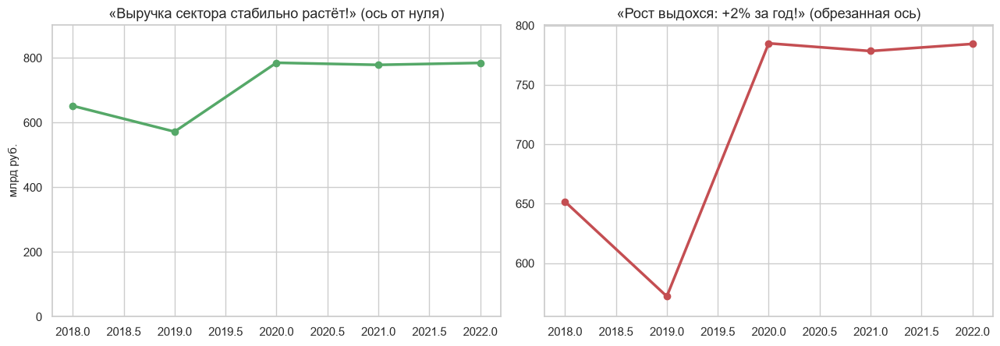


**Критический комментарий.** Оба графика построены по одним данным — различие только в масштабе
оси. Честная интерпретация: выручка сектора выросла с X до Y млрд руб., но темп роста замедляется,
при этом число компаний в реестре **сокращается** — рост выручки обеспечивается «укрупнением»
выживших, а не расширением сектора. Внешние факторы, искажающие вывод:
- изменение методики ведения реестра МСП ФНС (критерии пересматривались в 2021 г. — база сравнения неоднородна);
- пандемийный 2020 г. (разовый спрос на текстиль/маски завысил базу);
- данные ФНС о «доходах-расходах» отражают финансовый результат, а не оборот (нулёвки — это убытки).


In [49]:
# Один и тот же показатель — два противоположных заголовка
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
d1 = dyn.copy()
axes[0].plot(d1["year"], d1["revenue_bln"], "o-", color="#55A868", lw=2.5)
axes[0].set_ylim(0, d1["revenue_bln"].max() * 1.15)
axes[0].set_title("«Выручка сектора стабильно растёт!» (ось от нуля)")
axes[0].set_ylabel("млрд руб.")
axes[1].plot(d1["year"], d1["revenue_bln"], "o-", color="#C44E52", lw=2.5)
axes[1].set_ylim(d1["revenue_bln"].min() * 0.97, d1["revenue_bln"].max() * 1.02)
axes[1].set_title("«Рост выдохся: +2% за год!» (обрезанная ось)")
axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

manipulation = """
**Критический комментарий.** Оба графика построены по одним данным — различие только в масштабе
оси. Честная интерпретация: выручка сектора выросла с X до Y млрд руб., но темп роста замедляется,
при этом число компаний в реестре **сокращается** — рост выручки обеспечивается «укрупнением»
выживших, а не расширением сектора. Внешние факторы, искажающие вывод:
- изменение методики ведения реестра МСП ФНС (критерии пересматривались в 2021 г. — база сравнения неоднородна);
- пандемийный 2020 г. (разовый спрос на текстиль/маски завысил базу);
- данные ФНС о «доходах-расходах» отражают финансовый результат, а не оборот (нулёвки — это убытки).
"""
display(Markdown(manipulation))

## 6.3. Стоимость ошибки («что если данные врут на 10%»)

In [50]:
total_2022 = dyn.loc[dyn["year"] == 2022, "revenue_bln"].iloc[0]
emp_2022 = con.execute(
    "SELECT SUM(employees_count) FROM mart_yearly WHERE year = 2022"
).fetchone()[0]
comp_2022 = int(dyn.loc[dyn["year"] == 2022, "companies"].iloc[0])
err = pd.DataFrame({
    "Сценарий ошибки": ["Прогноз занижен на 10%", "Прогноз завышен на 10%"],
    "Δ выручки сектора, млрд руб.": [round(total_2022 * 0.10, 1), round(-total_2022 * 0.10, 1)],
    "Последствие для решения": [
        "Недофинансирование программ поддержки: упущенная выручка отрасли, риск банкротств микропредприятий",
        "Неэффективное распределение бюджета поддержки: субсидии «сгорят» в перекапитализированных компаниях",
    ],
})
display(err)
cost_comment = f"""
**Оценка.** 10%-я ошибка в оценке выручки сектора ({total_2022:.0f} млрд руб. в 2022 г.) — это
±{total_2022*0.10:.0f} млрд руб. неверно адресованных решений. Через сектор занято
~{emp_2022:,.0f} человек (по {comp_2022:,} компаниям с отчётностью), т.е. ошибка в 10%
эквивалентна рискам для тысяч рабочих мест. Вывод: перед принятием решений модель обязана
дообучаться на свежих данных ФНС и публиковаться с интервальной оценкой (см. п. 4.2).
""".replace(",", " ")
display(Markdown(cost_comment))

,Сценарий ошибки,"Δ выручки сектора, млрд руб.",Последствие для решения
0,Прогноз занижен на 10%,78.40,Недофинансирование программ поддержки: упущенн...
1,Прогноз завышен на 10%,-78.40,Неэффективное распределение бюджета поддержки:...



**Оценка.** 10%-я ошибка в оценке выручки сектора (784 млрд руб. в 2022 г.) — это
±78 млрд руб. неверно адресованных решений. Через сектор занято
~195 901 человек (по 15 195 компаниям с отчётностью)  т.е. ошибка в 10%
эквивалентна рискам для тысяч рабочих мест. Вывод: перед принятием решений модель обязана
дообучаться на свежих данных ФНС и публиковаться с интервальной оценкой (см. п. 4.2).


# <a id="etap7"></a>Итоговый отчёт

## Сводка результатов по этапам

| Этап | Результат |
|---|---|
| 1. Сбор и подготовка | 4 таблицы ФНС очищены (0 дубликатов, даты типизированы), данные обезличены (SHA-256+соль), паспорт данных составлен, `output/smb_clean_anonymized.csv` выгружен |
| 2. Хранение и ETL | Развёрнута СУБД DuckDB (OLAP, локально — 242-ФЗ), схема «звезда», витрина `mart_yearly`, контрольные суммы сошлись; контрольное задание выполнено (топ-3 региона — см. п. 2.4) |
| 3. Аналитика | 5 выводов + карта России + аномалии: столичный перекос, Ивановская область — 2-е место по выручке, тесная связь выручки и численности (r = 0.66, эластичность ≈ 1) |
| 4. Прогнозы | Линейный тренд и экстраполяция на 2023 г.; сравнение CatBoost и RandomForest (метрики ниже); сценарии «расходы +5/10/15/20%»; 4 кластера регионов |
| 5. Дашборд | Интерактивный BI-отчёт с селекторами, KPI-карточками, картой и прогнозной зоной |
| 6. Бизнес-блок | Паспорт обработки 152-ФЗ, журнал аудита в СУБД, кейс «интерпретация vs манипуляция», оценка стоимости ошибки 10% |

## Ключевые количественные итоги (вычисляются по факту выполнения)

In [51]:
summary_md = f"""
**Контрольное задание (этап 2):** топ-3 региона по средней выручке компании —
{', '.join(f'{r.region} ({r.avg_revenue_mln:.0f} млн руб.)' for r in t3.itertuples())};
среднее по топ-3 = **{t3['avg_revenue_mln'].mean():.0f} млн руб.**

**Прогноз сектора (этап 4.2):** тренд {k:+.1f} млрд руб./год, прогноз выручки на 2023 г. =
**{pred_2023:.0f} млрд руб.** (±{1.96*resid_std:.0f}).

**ML-модели (этап 4.4–4.5):**
""" + res_df.to_markdown(index=False) + f"""

Лучшая модель — **{best}**: медианная ошибка прогноза — множитель ×{10**res_df['MAE (log10)'].min():.1f} по выручке.

**Неочевидная история:** география выручки (столицы) ≠ география занятости (текстильные регионы):
деньги зарабатываются по месту регистрации юрлица, рабочие места — по месту цеха.
"""
display(Markdown(summary_md))


**Контрольное задание (этап 2):** топ-3 региона по средней выручке компании —
Республика Алтай (161 млн руб.), Карачаево-Черкесская республика (121 млн руб.), Магаданская область (120 млн руб.);
среднее по топ-3 = **134 млн руб.**

**Прогноз сектора (этап 4.2):** тренд +47.2 млрд руб./год, прогноз выручки на 2023 г. =
**856 млрд руб.** (±111).

**ML-модели (этап 4.4–4.5):**
| Модель       |   MAE (log10) |   RMSE (log10) |    R² |   Множитель ошибки (×) |
|:-------------|--------------:|---------------:|------:|-----------------------:|
| CatBoost     |         0.294 |          0.508 | 0.718 |                   1.97 |
| RandomForest |         0.3   |          0.514 | 0.71  |                   1.99 |

Лучшая модель — **CatBoost**: медианная ошибка прогноза — множитель ×2.0 по выручке.

**Неочевидная история:** география выручки (столицы) ≠ география занятости (текстильные регионы):
деньги зарабатываются по месту регистрации юрлица, рабочие места — по месту цеха.


## Ответы на ключевые вопросы работы
- **Почему именно эти регионы в топ-3 (контрольное задание):** по *средней* выручке лидируют малые регионы, где одну-две компании-гиганта делит горстка организаций (эффект малого знаменателя, медианы в десятки раз ниже средних); устойчивый рейтинг — по *суммарной* выручке: Москва, Ивановская область (текстильный кластер), Московская область.
- **Неочевидная история данных:** «лёгкая промышленность МСП» — это два разных мира: тысячи микропредприятий (медианная выручка — единицы млн руб.) и десятки компаний-гигантов в реестре; при этом география выручки (столицы) ≠ география занятости (текстильные регионы) — поддержка «по выручке» укрепит офисы, а не цеха.
- **Прогноз:** при сохранении тренда выручка сектора 2023 г. — см. расчёт выше; на уровне компании лучший прогноз даёт CatBoost.

## Ограничения исследования
1. Финансовые данные ФНС — только 2018–2022, агрегаты по годам (сезонность не оценивается напрямую, показан след на месячных данных реестра).
2. 21% наблюдений с нулевым/отрицательным финансовым результатом исключены из ML-выборки (лог-шкала) — модель описывает «действующие» компании.
3. Реестр МСП пересматривался методически (2021 г.) — межгодовые сравнения имеют структурные разрывы.

In [52]:
con.close()
print("СУБД закрыта. Лабораторная работа завершена.")

СУБД закрыта. Лабораторная работа завершена.


In [53]:
from IPython.display import HTML
HTML("<div style='padding:12px;border:2px solid #4C72B0;border-radius:8px'>"
     "<b>Артефакты работы:</b> output/lab01.duckdb (хранилище + аудит), "
     "output/smb_clean_anonymized.csv (очищенные данные), Lab01_BigData.ipynb (код и графики)</div>")